
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily | Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly | Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---

## Notebook Structure

| Part | Description |
|---|---|
| **Part 1 — Setup & Data Loading** | Imports, parameters, download/read data, save CSVs, sanity check, load MIDAS order-level data |
| **Part 2 — Core Analytical Functions & Volume Feature Engineering** | Define all helper functions (ATR, SMA, `add_volume_features`, pivot detection, zone builder, chart, MIDAS enrichers); apply volume features to both timeframes |
| **Part 3 — Daily (HTF) Analysis** | Build and visualise liquidity zones on the daily timeframe; compare zone tables with and without order-level data |
| **Part 4 — Hourly (LTF) Analysis** | Build and visualise liquidity zones on the hourly timeframe; compare zone tables with and without order-level data |
| **Part 5 — Export Results** | Write all outputs to Excel — separate MIDAS comparison sheets included when `USE_MIDAS = True` |



## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [62]:

# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW     = 20    # rolling window for average volume; smooths single-bar noise to give a reliable activity baseline
VOL_SPIKE_THRESHOLD = 1.5   # vol_ratio >= threshold marks a spike; bars above this likely reflect institutional participation
USE_VOL_FILTER      = True  # when True, only sweeps with elevated volume are flagged, filtering low-conviction breakouts
VOL_PROFILE_BIN_DAILY  = 1.0   # $1 USD bin width for daily POC — coarser bin fits the multi-year price range
VOL_PROFILE_BIN_HOURLY = 0.5   # $0.50 USD bin width for hourly POC — finer bin for intraday price levels

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True  # when True, enrich zones and sweeps with MIDAS institutional microstructure features;
                  # enables side-by-side comparison of analysis with and without order-level data

# ---------------------------------------------------------------------------
# Intraday sweep detection config (LTF focus — three-layer zone filtering)
# ---------------------------------------------------------------------------
# Layer 1: ATR/pivot structure          
# Layer 2: volume + absorption filter   
# Layer 3: MIDAS institutional enrichment filter

MIN_ABSORPTION_SCORE = 0.5   # Layer 2: minimum absorption_score for LTF zone pivots (STRUCTURAL);
                              # a high score means heavy volume with a small candle body —
                              # the bar-level footprint of institutional orders absorbing at a level;
                              # set to 0.0 to disable (HTF context zones use 0.0 by default)

# Intraday-optimized parameters (same-day zone detection)
INTRADAY_ABSORPTION_SCORE = 0.3   # Reduced from 0.5 for hourly feasibility
INTRADAY_PIVOT_WINDOW = 3          # Reduced from 5 hours (too restrictive for intraday)
INTRADAY_VOL_MULT = 1.2            # Increased from 1.0 for actual volume spike detection
INTRADAY_MIN_TOUCHES = 1            # Reduced from 2 for single-bar reversals

MIDAS_CONFIRM_FIELD  = "hidden_rate_avg"  # Layer 3: MIDAS zone column used for institutional enrichment filtering;
                                          # options: "hidden_rate_avg"      (dark-pool execution fraction)
                                          #          "cancel_to_trade_avg"  (algo probing / spoofing intensity)
                                          #          "fill_rate_avg"        (inverse: low fill = iceberg/spoof)

MIDAS_CONFIRM_PCT    = 50    # Layer 3: percentile threshold for the MIDAS institutional filter (0–100):
                              #   50 = keep zones above median institutional activity (moderate filter)
                              #   75 = keep only top quartile (strict — fewer, higher-conviction zones)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")
print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"POC bins   : daily=${VOL_PROFILE_BIN_DAILY}  |  hourly=${VOL_PROFILE_BIN_HOURLY}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"LTF filter : min_absorption={MIN_ABSORPTION_SCORE}  |  MIDAS_CONFIRM_FIELD={MIDAS_CONFIRM_FIELD}  |  MIDAS_CONFIRM_PCT={MIDAS_CONFIRM_PCT}th pct")


Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-2/data/raw
Vol window : 20  |  Spike threshold : 1.5  |  Vol filter : True
POC bins   : daily=$1.0  |  hourly=$0.5
MIDAS data : enabled
LTF filter : min_absorption=0.5  |  MIDAS_CONFIRM_FIELD=hidden_rate_avg  |  MIDAS_CONFIRM_PCT=50th pct


In [63]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [64]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-2/data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [65]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data/raw/TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv


In [66]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
display(reload_daily.head(3))
print("Hourly head:")
display(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:


,Close,High,Low,Open,Volume
Datetime,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000


Hourly head:


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254


In [67]:
# Diagnostic: Identify days with mixed zero/valid volumes
print("\n" + "="*70)
print("MIXED-VOLUME DAYS DIAGNOSTIC")
print("="*70)

reload_hourly_diag = reload_hourly.copy()
reload_hourly_diag['date'] = reload_hourly_diag.index.normalize()

mixed_volume_days = []
for date_val in reload_hourly_diag['date'].unique():
    day_data = reload_hourly_diag[reload_hourly_diag['date'] == date_val]
    zero_count = (day_data['Volume'] == 0).sum()
    valid_count = (day_data['Volume'] > 0).sum()
    
    # Mixed if both zero and valid hours exist
    if zero_count > 0 and valid_count > 0:
        avg_valid = day_data[day_data['Volume'] > 0]['Volume'].mean()
        mixed_volume_days.append({
            'date': date_val,
            'zero_hours': zero_count,
            'valid_hours': valid_count,
            'avg_valid_vol': avg_valid,
            'total_hours': len(day_data)
        })

print(f"Found {len(mixed_volume_days)} days with mixed zero/valid volumes")
if len(mixed_volume_days) > 0:
    print(f"\nExamples of mixed-volume days (first 10):")
    mixed_df = pd.DataFrame(mixed_volume_days).head(10)
    display(mixed_df)
else:
    print("\n✓ No mixed-volume days found - all zero hours can be filled intelligently")



MIXED-VOLUME DAYS DIAGNOSTIC
Found 40 days with mixed zero/valid volumes

Examples of mixed-volume days (first 10):


,date,zero_hours,valid_hours,avg_valid_vol,total_hours
0,2021-03-23,5,2,17071111.5,7
1,2021-03-24,1,6,14270567.0,7
2,2021-04-09,2,5,5200600.8,7
3,2021-04-16,1,6,6503535.5,7
4,2021-05-10,1,6,12973128.5,7
5,2021-05-14,1,6,7354025.5,7
6,2021-05-24,2,5,5906889.6,7
7,2021-06-07,2,5,2349012.6,7
8,2021-08-09,2,5,2725462.2,7
9,2021-08-31,2,5,5406672.6,7


In [68]:

# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics 
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

if USE_MIDAS:
    midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
    midas_df["date"] = pd.to_datetime(midas_df["date"])
    midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
    midas_df.index = midas_df.index.normalize()   # strip any time-of-day component

    print(f"MIDAS rows   : {len(midas_df)}")
    print(f"Date range   : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
    print(f"Columns      : {midas_df.columns.tolist()}")
    display(midas_df.describe().round(3))
else:
    midas_df = None
    print("USE_MIDAS = False — MIDAS data not loaded.")


MIDAS rows   : 941
Date range   : 2021-01-04 -> 2024-09-30
Columns      : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']


,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
count,941.000,941.000,941.000,941.000,941.000,941.000
mean,18.853,30.190,25.196,3.608,82.085,39.133
std,6.782,8.664,6.648,1.441,8.205,12.850
min,5.700,12.183,10.479,1.115,63.536,19.275
25%,13.630,21.986,19.441,2.498,74.979,27.657
50%,18.270,31.953,25.270,3.318,79.392,32.750
75%,22.839,38.154,30.926,4.519,90.533,51.566
max,46.722,45.673,44.220,10.498,94.521,63.703


## Part 1.5 Data Quality & Exploratory Data Analysis (EDA)

Before proceeding with zone and sweep detection, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal / cyclical patterns:** decomposition of price and volume time series



In [69]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
display(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
display(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (941, 5)
Date range: 2021-01-04 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:


,Close,High,Low,Open,Volume
count,941.00,941.00,941.00,941.00,9.410000e+02
mean,237.46,242.79,232.06,237.60,1.008086e+08
std,54.69,56.12,53.31,54.89,4.023200e+07
min,108.10,111.75,101.81,103.00,2.940180e+07
25%,197.41,201.78,192.20,197.32,7.114590e+07
50%,233.94,238.47,228.18,233.87,9.391650e+07
75%,266.68,273.17,261.20,267.48,1.208318e+08
max,409.97,414.50,405.67,411.47,3.065906e+08



SANITY CHECK — HOURLY (LTF) DATA
Shape: (6577, 6)
Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Open        float64
High        float64
Low         float64
Close       float64
% Change     object
Volume        int64
dtype: object

Numeric summary:


,Open,High,Low,Close,Volume
count,6577.00,6577.00,6577.00,6577.00,6.577000e+03
mean,237.54,239.31,235.66,237.51,1.327944e+07
std,54.77,55.23,54.25,54.74,1.094012e+07
min,103.00,106.48,101.81,105.67,0.000000e+00
25%,197.38,198.83,195.50,197.38,6.503731e+06
50%,233.75,235.15,231.87,233.73,1.038073e+07
75%,267.33,269.06,265.41,267.27,1.669884e+07
max,413.02,414.50,410.57,412.93,1.374730e+08



---
Daily rows with zero/negative volume: 0
Hourly rows with zero/negative volume: 264

Alignment check:
  Daily dates not in hourly: 0 day(s)


In [70]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    # Use 6.5 as typical, but adjust based on market conditions
                    hourly_fill_vol = daily_vol / 6.5
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 941

Hourly volume:
  Missing values: 0
  Zero values: 264
  Total valid: 6313

→ Found 264 bars with missing or zero hourly volume
  Analyzing mixed-volume days...



/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_39968/505545097.py:48: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17071111.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



✓ Filled 264 bars
  - 138 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 137473011


In [71]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
display(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):


,Daily_Volume,Hourly_Volume,Ratio (Hourly/Daily)
Datetime,,,
2021-01-04,145914600,138854073.0,1.0
2021-01-05,96735600,87119124.0,1.0
2021-01-06,134100000,129531942.0,1.0
2021-01-07,154496700,145369788.0,1.0
2021-01-08,225166500,219834303.0,1.0
2021-01-11,177904800,172612128.0,1.0
2021-01-12,138812100,132122601.0,1.0
2021-01-13,99937500,94706133.0,1.0
2021-01-14,93798900,91119210.0,1.0



Average Hourly/Daily ratio: 0.9343
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


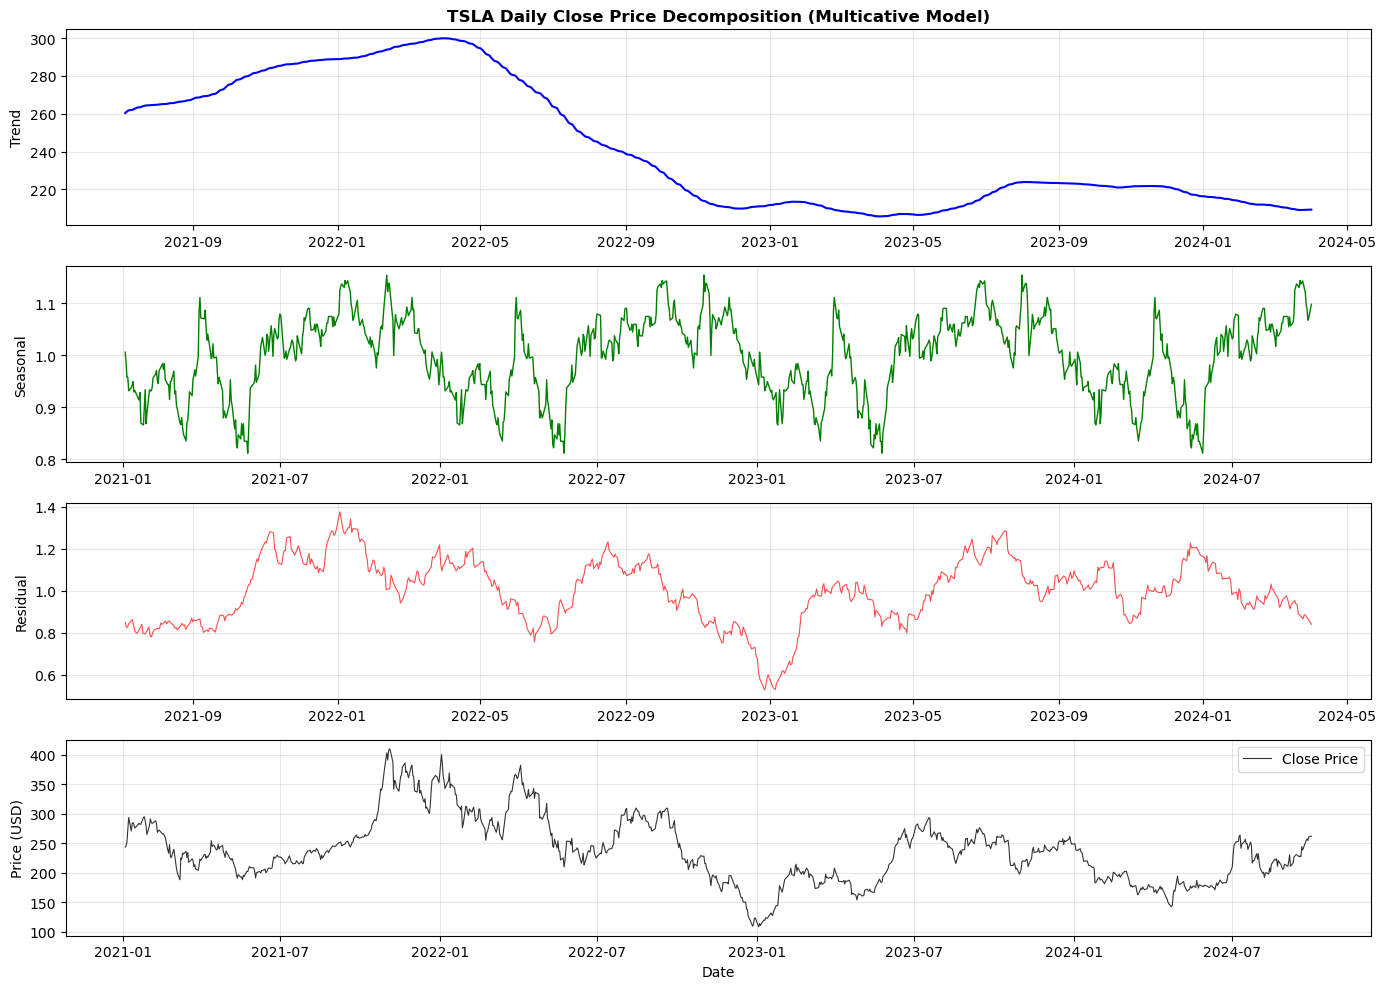

Saved: outputs/eda_decomposition.png


In [72]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_39968/2554135952.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



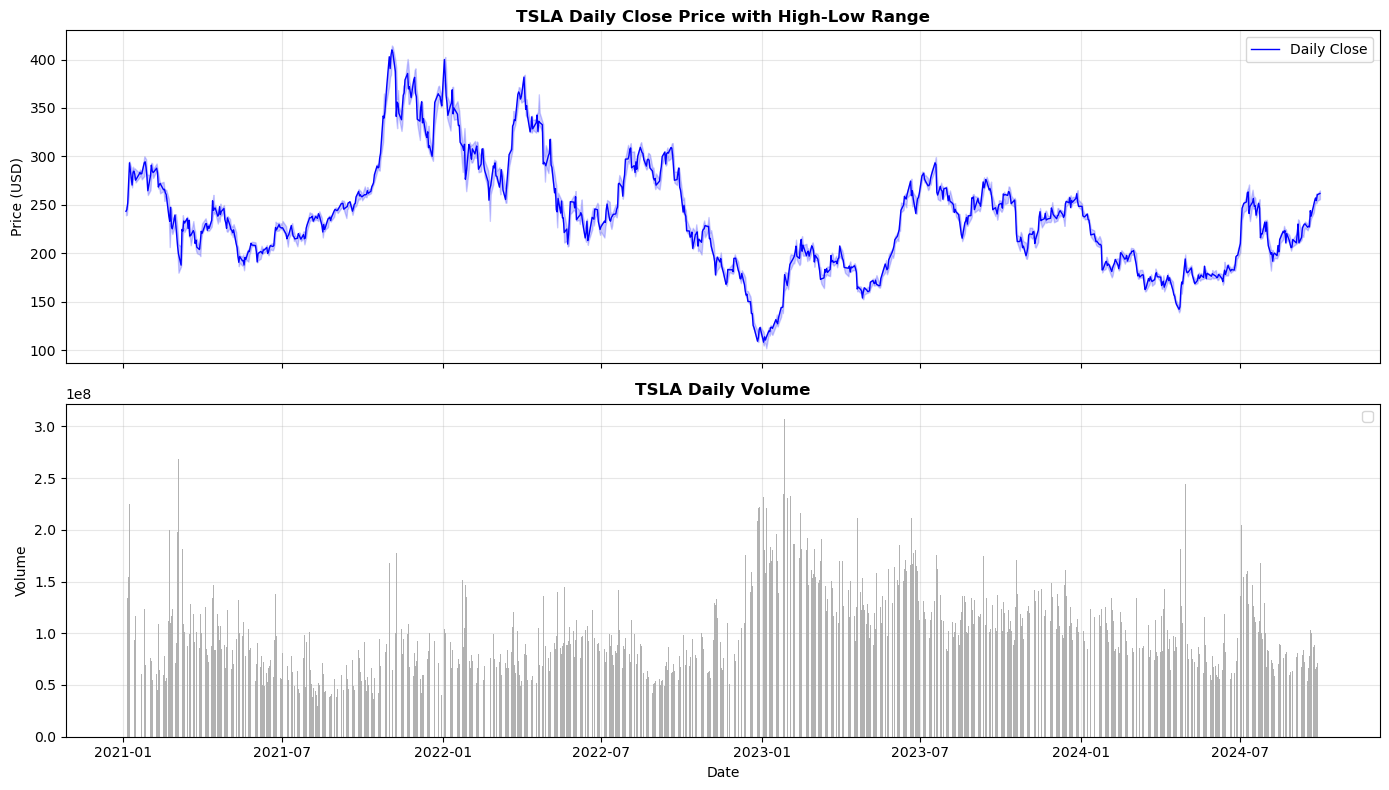

Saved: outputs/eda_price_volume.png


In [73]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")


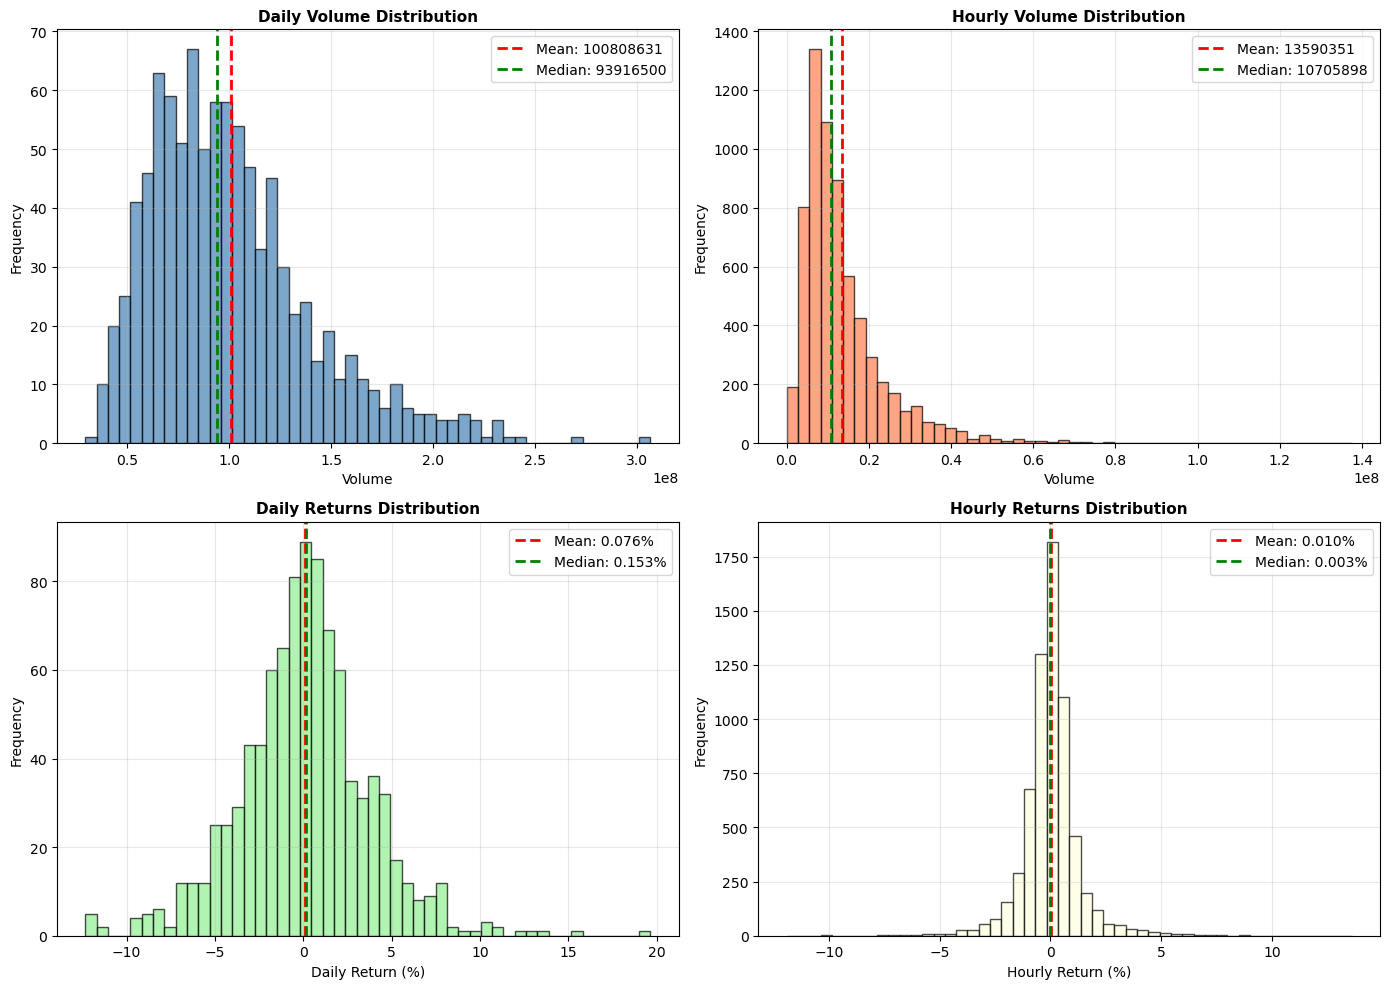

Saved: outputs/eda_distributions.png


In [74]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


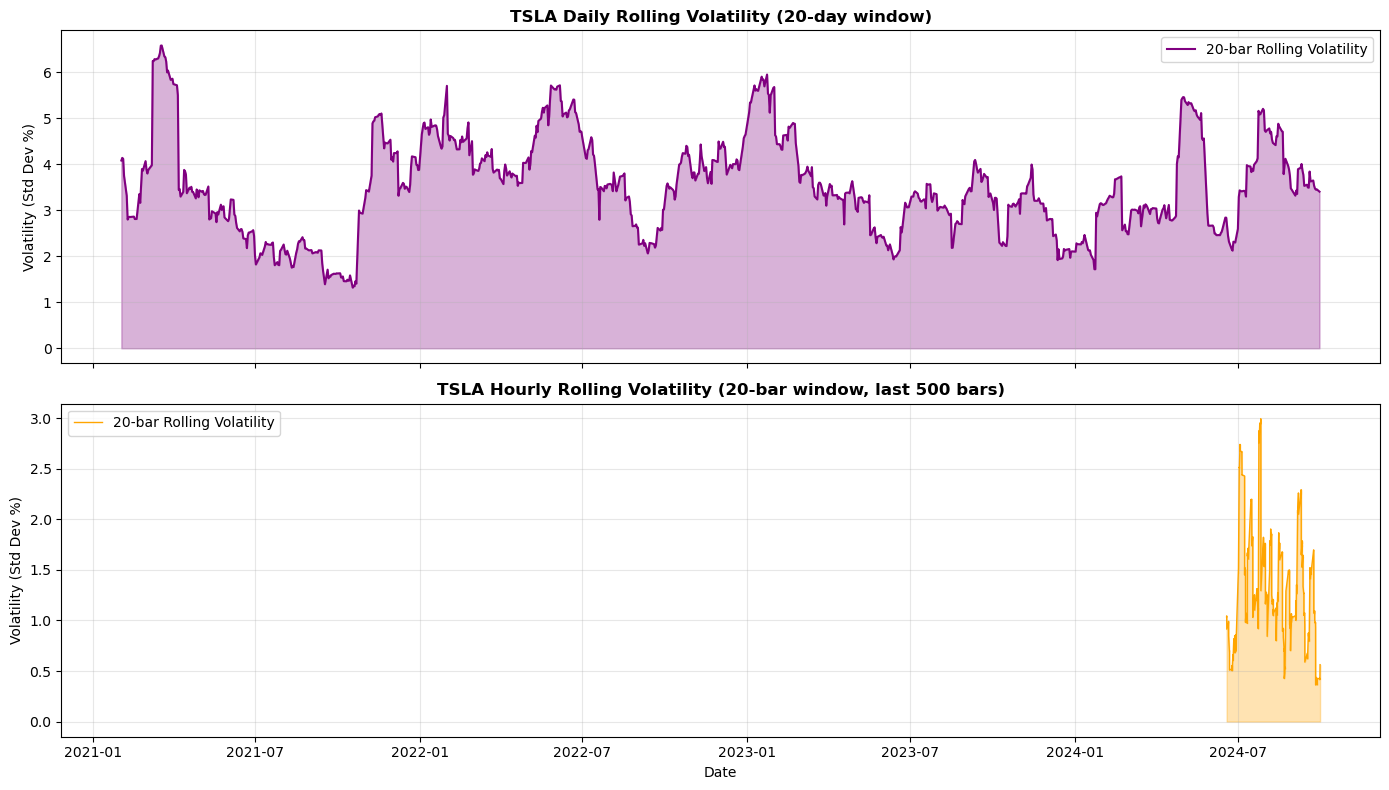

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.5182%, Std: 1.0546%, Max: 6.5815%
Hourly volatility - Mean: 1.2262%, Std: 0.5033%, Max: 4.1117%


In [75]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [76]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
display(summary_df)


EDA SUMMARY — DAILY vs HOURLY


,Metric,Daily (HTF),Hourly (LTF)
0,Records,941,6577
1,Date Range,2021-01-04 to 2024-09-30,2021-01-04 09:30:00 to 2024-09-30 15:30:00
2,Avg Close,237.46,237.51
3,Min Close,108.10,105.67
4,Max Close,409.97,412.93
5,Avg Volume,100808631,13590351
6,Median Volume,93916500,10705898
7,Volume Std Dev,40231996,10742500
8,Avg Return (%),0.0757,0.0097
9,Max Return (%),19.6412,13.6053




## Part 2 — Core Analytical Functions & Volume Feature Engineering

The cells below define all helper functions used in the analysis, including volume feature engineering, MIDAS order-level enrichment, and the three-layer zone filter.

### ⚠️ IMPORTANT: Overlapping Events & Zone Handling

**Current behavior:**
- **Zones are merged** when new pivots cluster within `atr_merge_mult × ATR(14)` and occur within 90 days (`max_merge_gap_days = 90`). This merging is **intentional and correct** — nearby pivots represent the same institutional liquidity level and should be unified into a single zone.
- **However, non-overlapping independent zones CAN and DO coexist simultaneously** — price can be between two separate zones without issue.
- **Sweeps match to multiple zones:** In `tag_sweeps_at_zones()`, sweeps are matched to zones using distance-based proximity rules (`proximity_atr_mult = 0.25`). **A single sweep bar CAN trigger proximity to multiple distinct zones** (e.g., sweep occurs equidistant from two separate levels). The current logic captures only the **first matching zone** (line "matched_zone_id = zid; break"), not all overlapping zones.
- **No explicit de-duplication:** If a sweep occurs at a price level where multiple non-merged zones exist (or fall within proximity of multiple zones), only one zone assignment is recorded.

**Recommendation for enhanced analysis:**
1. **For individual trade signal generation:** Continue with single zone assignment (current behavior). The "first match" rule is unambiguous.
2. **For institutional footprint analysis:** Optionally collect **all matching zone IDs** per sweep (modify `tag_sweeps_at_zones()` to return a list instead of a single ID). This reveals whether a sweep occurred at a confluence of multiple independent liquidity pools.
3. **For backtesting:** Track both single and multi-zone sweep subsets separately to compare signal quality — multi-zone sweeps may have higher conviction due to liquidity confluence.

**Current gaps to consider:**
- No filtering of temporally-overlapping zones (e.g., a zone active on 2021-01-15 with another active 2021-01-20 that share price space).
- No ranking of zone "overlaps" by institutional strength (does overlap occur at the POC?).
- Sweep-zone proximity is fixed (`proximity_atr_mult=0.25`), not adaptive to zone age or strength.

**Summary:** The current design is sound for structural pivot clustering (zones are merged correctly). To unlock multi-zone sweep analysis, a small enhancement to `tag_sweeps_at_zones()` is needed — change from single match to list collection.

---

### Helper Functions

| Function | Purpose |
|---|---|
| `atr()` / `sma()` | Average True Range and Simple Moving Average |
| `add_volume_features()` | Append `vol_roll_20`, `vol_ratio`, `vol_spike`, and `absorption_score` to any OHLCV frame |
| `detect_pivots()` | Identify structural pivot highs and lows using a symmetric window |
| `Zone` (dataclass) | Container storing a zone's price bounds, metadata, and volume aggregates |
| **`identify_liquidity_zones()`** | **Main entry point — all three layers in one function.** Layer 1: pivot detection. Layer 2: volume + absorption filter. POC enrichment. Layer 3: MIDAS enrichment + filter. Returns both baseline and MIDAS-enriched zone sets. |
| `compute_volume_poc()` | Bin prices into fixed-width USD bands and find the highest-volume bin (Point of Control) |
| `compute_anchored_vwaps()` | VWAP anchored from the `first_time` of the top-N zones by strength |
| `add_sweep_avwap_dist()` | Attach `dist_to_nearest_avwap` to each sweep bar |
| `enrich_zones_midas()` | **Layer 3a:** Average MIDAS microstructure metrics over each zone's active window |
| `enrich_sweeps_midas()` | Attach each bar's daily MIDAS values by calendar date (works for daily and intraday) |
| `get_midas_enriched_zones()` | **Layer 3b:** Filter zones to those above the Nth percentile of a MIDAS metric |
| `detect_liquidity_sweeps()` | Flag bars that spike through a prior pivot but close back inside; attaches sweep-bar volume columns |
| `tag_sweeps_at_zones()` | Label sweeps that occur near a known liquidity zone |
| `plot_zones_matplotlib()` | Render price, pivots, and zones on a chart and save to disk |

### Three-Layer Zone Filter (LTF Primary)

| Layer | What it does | Relevant parameter |
|---|---|---|
| **Layer 1** | ATR/pivot: find local highs/lows using symmetric window | `pivot_left_right`, `atr_merge_mult` |
| **Layer 2a** | Volume: pivot bar volume > `vol_mult × rolling average` | `vol_mult`, `require_volume` |
| **Layer 2b** | Absorption: pivot bar must have `absorption_score ≥ MIN_ABSORPTION_SCORE` | `MIN_ABSORPTION_SCORE` |
| **Layer 3a** | MIDAS enrich: average institutional metrics over each zone's active window | `USE_MIDAS` |
| **Layer 3b** | MIDAS filter: retain only zones above the Nth percentile of chosen metric | `MIDAS_CONFIRM_FIELD`, `MIDAS_CONFIRM_PCT` |

### Volume Feature Columns

| Column | Formula | Description |
|---|---|---|
| `vol_roll_20` | `volume.rolling(20).mean()` | Rolling volume baseline; judges whether a pivot bar reflects genuine institutional interest |
| `vol_ratio` | `volume / vol_roll_20` | Relative volume — values above 1.5 indicate elevated participation; key qualifier for valid zone pivots |
| `vol_spike` | `vol_ratio ≥ VOL_SPIKE_THRESHOLD` | Flags high-conviction pivot bars where stop-cluster activity is likely concentrated |
| `absorption_score` | `vol_ratio / max(│close−open│ / ATR₁₄, 0.01)` | High = heavy volume, small body — footprint of institutional orders absorbing supply or demand at a level |

### Zone-Level Feature Columns

| Column | Description |
|---|---|
| `total_volume` | Cumulative pivot-bar volume at the zone |
| `avg_volume` | Average pivot-bar volume per touch |
| `volume_node_score` | Total volume of bars closing within ±0.5 % of zone mid |
| `strength` | `touches × recency_factor × log1p(total_volume)` |
| `avg_absorption` | Mean `absorption_score` of bars that touched the zone; high = strong institutional soaking footprint |
| `dist_to_poc` | `│zone_mid − poc_price│`; lower = zone sits at the peak trading level |
| `poc_volume_ratio` | `volume_node_score / poc_volume`; fraction of POC bin volume transacted at the zone |

### Sweep-Level Feature Columns

| Column | Description |
|---|---|
| `sweep_vol` / `sweep_vol_ratio` / `sweep_vol_spike` | Volume context at the sweep bar |
| `dist_to_nearest_avwap` | Min distance from sweep close to any active anchored VWAP; small = sweep at institutional fair value |

### MIDAS Order-Level Feature Columns — Zone-Level

Added by `enrich_zones_midas()` inside `identify_liquidity_zones()` when `midas_df` is provided. Each value is the **mean** of the MIDAS field across all trading days in the zone's `first_time → last_time` window.

| Column | Source Field | Interpretation |
|---|---|---|
| `cancel_to_trade_avg` | `Cancel_to_Trade` | Elevated average signals persistent algorithmic probing / spoofing at this price level before a sweep |
| `hidden_rate_avg` | `Hidden_Rate` | High fraction = institutional orders routing to dark pools to avoid market impact at this zone |
| `hidden_volume_avg` | `Hidden_Volume` | Volume-weighted complement to `hidden_rate_avg`; confirms whether dark-pool activity was large or small-size |
| `fill_rate_avg` | `Trade_to_Order_Volume` | Persistently low fill rate near a zone suggests iceberg or spoof orders protecting the level |
| `oddlot_rate_avg` | `Oddlot_Rate` | High odd-lot rate = retail fragmentation; institutions are likely on the opposite side of the zone |
| `oddlot_volume_avg` | `Oddlot_Volume` | Odd-lot volume fraction; supplementary to `oddlot_rate_avg` |

### MIDAS Order-Level Feature Columns — Sweep-Level

Added by `enrich_sweeps_midas()` when `USE_MIDAS = True`. Each value is the MIDAS reading for the **calendar day** of the sweep bar.

| Column | Source Field | Interpretation |
|---|---|---|
| `sweep_cancel_to_trade` | `Cancel_to_Trade` | Spike on sweep day = algo probing intensified as stop-raid was executed |
| `sweep_hidden_rate` | `Hidden_Rate` | High on sweep day = institutions routing sweep-day orders through dark pools |
| `sweep_hidden_volume` | `Hidden_Volume` | Volume-weighted confirmation of dark-pool activity on the sweep day |
| `sweep_fill_rate` | `Trade_to_Order_Volume` | Low fill rate on sweep day = order-flow manipulation coinciding with the sweep |
| `sweep_oddlot_rate` | `Oddlot_Rate` | Retail fragmentation on sweep day |
| `sweep_oddlot_volume` | `Oddlot_Volume` | Odd-lot volume fraction on sweep day |

> The MIDAS-enriched zone set (`zones_df_hourly_enriched`) and sweep table (`sweeps_tagged_hourly_enriched`) form the **"with order-level data"** feature set. The Layer 1+2 zone set and `sweeps_tagged_hourly` form the **"without order-level data"** baseline.

### Config Constants (set in Part 1)

| Constant | Default | Meaning |
|---|---|---|
| `VOL_ROLL_WINDOW` | 20 | Rolling window for the volume baseline |
| `VOL_SPIKE_THRESHOLD` | 1.5 | Minimum `vol_ratio` to flag a volume spike |
| `USE_VOL_FILTER` | `True` | When `True`, sweep detection requires a volume spike |
| `VOL_PROFILE_BIN_DAILY` | 1.0 | USD bin width for daily volume profile / POC |
| `VOL_PROFILE_BIN_HOURLY` | 0.5 | USD bin width for hourly volume profile / POC |
| `USE_MIDAS` | `True` | When `True`, attach MIDAS order-level features to zone and sweep tables |
| `MIN_ABSORPTION_SCORE` | 0.5 | Layer 2b: minimum absorption_score for LTF zone pivots (0.0 = disabled) |
| `MIDAS_CONFIRM_FIELD` | `"hidden_rate_avg"` | Layer 3b: MIDAS zone column used as the institutional enrichment metric |
| `MIDAS_CONFIRM_PCT` | 50 | Layer 3b: percentile threshold — zones at or above this pass the MIDAS institutional filter |

In [77]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR, SMA, and Volume Features
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()


def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Appends rolling volume features and absorption score to *df*.
    Handles both 'volume' (lowercase) and 'Volume' (title-case) column names.

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **BIAS MITIGATION — Z-Score Normalization:**
    When use_z_score_normalization=True, vol_ratio_zscore is added in z-score units (μ=0, σ=1).
    This removes regime bias from high-volatility periods where absolute volume is naturally higher.
    Institutional activity thresholds become market-regime-independent.

    Columns appended:
      vol_roll_20             : rolling mean volume over `window` bars
      vol_roll_std            : rolling std for z-score normalization
      vol_ratio               : volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold
      absorption_score        : vol_ratio / (|close-open| / ATR_14), clipped at denominator >= 0.01;
                               high score = heavy volume with small candle body, institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_volume_features: no volume column found — skipping.")
        return df

    vol = df[vol_col].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    df["vol_ratio"]   = vol / df["vol_roll_20"]
    
    # Z-score normalization — removes regime bias
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    df["vol_spike"]   = df["vol_ratio"] >= spike_threshold

    # Absorption score — works regardless of column case by normalising to lowercase
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if all(c in df_n.columns for c in ["high", "low", "close", "open"]):
        _atr      = atr(df_n, length=14)
        bar_body  = (df_n["close"] - df_n["open"]).abs()
        body_norm = (bar_body / _atr.replace(0, np.nan)).clip(lower=0.01)
        df["absorption_score"] = (df["vol_ratio"] / body_norm.values).values

    return df


In [78]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
display(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))
print("\nLTF (hourly) vol sample:")
display(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

HTF (daily) vol sample:


,vol_roll_20,vol_ratio,vol_spike,absorption_score
Datetime,,,,
2021-02-01,109662930.0,0.694621,False,1.016286
2021-02-02,106019130.0,0.688919,False,0.886856
2021-02-03,103933875.0,0.529476,False,0.852189



LTF (hourly) vol sample:


,vol_roll_20,vol_ratio,vol_spike,absorption_score
Datetime,,,,
2021-01-06 14:30:00,17300364.30,1.436791,False,2.356231
2021-01-06 15:30:00,15348341.55,0.618819,False,2.369715
2021-01-07 09:30:00,16059083.25,2.474446,True,2.554345


In [79]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

def compute_volume_poc(df: pd.DataFrame, bin_size: float = 1.0):
    """Bin all close prices into fixed-width USD bands and find the Point of Control.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    labels      = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    return float(vol_profile.idxmax()), float(vol_profile.max())

In [80]:
# ---------------------------------------------------------------------------
# Pivot Detection (Symmetric)
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out


In [81]:
# ---------------------------------------------------------------------------
# Zone Data Structure
# ---------------------------------------------------------------------------
@dataclass
class Zone:
    top: float
    bottom: float
    touches: int
    first_idx: int
    last_idx: int
    first_time: pd.Timestamp
    last_time: pd.Timestamp
    # Volume attributes — zones backed by high volume attract more stop orders and tend to hold as support/resistance
    total_volume: float = 0.0        # cumulative volume of the pivot bars that formed this zone
    avg_volume: float = 0.0          # average volume per pivot touch; normalises comparisons across zones
    volume_node_score: float = 0.0   # total volume of bars closing within ±0.5 % of zone mid
    strength: float = 0.0            # touches × recency_factor × log1p(total_volume); ranks zones by significance
    avg_absorption: float = 0.0      # mean absorption_score of bars that touched this zone; high = strong institutional soaking footprint

    @property
    def height(self) -> float:
        return float(self.top - self.bottom)


In [82]:
# ---------------------------------------------------------------------------
# MIDAS Zone Enrichment Helpers (Layer 3)
# ---------------------------------------------------------------------------
MIDAS_ZONE_COLS = [
    "cancel_to_trade_avg",
    "hidden_rate_avg",
    "hidden_volume_avg",
    "fill_rate_avg",
    "oddlot_rate_avg",
    "oddlot_volume_avg",
]


def enrich_zones_midas(zones_df: pd.DataFrame, midas_df: pd.DataFrame) -> pd.DataFrame:
    """Attach zone-level MIDAS averages over each zone's active date window."""
    out = zones_df.copy()
    if out.empty or midas_df is None or midas_df.empty:
        for col in MIDAS_ZONE_COLS:
            if col not in out.columns:
                out[col] = np.nan
        return out

    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "fill_rate_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Normalize MIDAS index to calendar dates for robust joins with daily/hourly bars.
    midas_norm = midas_df.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    for i, row in out.iterrows():
        start = pd.to_datetime(row["first_time"]).normalize()
        end = pd.to_datetime(row["last_time"]).normalize()
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        if window.empty:
            continue
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                out.at[i, dst_col] = float(window[src_col].mean())

    return out


def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    confirm_field: str = "hidden_rate_avg",
    percentile: float = 50,
 ) -> pd.DataFrame:
    """Filter zones by percentile threshold on a selected MIDAS confirmation metric."""
    if zones_df.empty or confirm_field not in zones_df.columns:
        return zones_df.copy()

    metric = pd.to_numeric(zones_df[confirm_field], errors="coerce").dropna()
    if metric.empty:
        return zones_df.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    out = zones_df[zones_df[confirm_field] >= threshold].copy().reset_index(drop=True)
    print(
        f"Layer 3 MIDAS filter ({confirm_field} >= {percentile}th pct = {threshold:.3f}): "
        f"{len(out)}/{len(zones_df)} zones retained"
    )
    return out

In [83]:
# ---------------------------------------------------------------------------
# identify_liquidity_zones — Single function applying all three layers:
#   Layer 1: ATR/pivot  — detect structural highs/lows
#   Layer 2: Volume + absorption — keep institutionally-significant pivots only
#   Layer 3: MIDAS enrichment + filter — retain high-conviction zones only
# Pass midas_df=None to skip Layer 3 (returns baseline zones only).
# ---------------------------------------------------------------------------
def identify_liquidity_zones(
    df: pd.DataFrame,
    # ── Layer 1+2 params ──────────────────────────────────────────────────────
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.0,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 2,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,      # Layer 2b: 0.0 disables (HTF); set MIN_ABSORPTION_SCORE for LTF
    # ── POC ───────────────────────────────────────────────────────────────────
    vol_profile_bin: float = 1.0, 
    # ── Zone Merging (temporal scope) ─────────────────────────────────────────
    max_merge_gap_days: int = 90,     # 90 for multi-day structural zones; 0 for same-day intraday zones
    # ── Layer 3: MIDAS ────────────────────────────────────────────────────────
    midas_df: pd.DataFrame = None,    # pass None to skip Layer 3 entirely 
    midas_confirm_field: str = "hidden_rate_avg",
    midas_confirm_pct: float = 50,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Optional[float], Optional[float]]:
    """
    Single entry point for liquidity zone identification — all three layers in one function.

    Returns:
        df_pivots      : price DataFrame annotated with pivot columns and zone_id
        zones_baseline : Layer 1+2 zone set (includes MIDAS feature columns if midas_df given)
        zones_enriched : Layer 1+2+3 MIDAS-filtered zone set; equals zones_baseline when midas_df=None
        poc_price      : Point of Control price (or None)
        poc_volume     : POC bin volume (or None)
    """

    # =========================================================================
    # LAYER 1: Pivot Detection
    # Identify structural highs/lows: high[i] is max (or low[i] is min) within
    # [i - pivot_left_right, i + pivot_left_right]. ATR sets the merge threshold.
    # =========================================================================
    out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    _has_volume     = "volume" in out.columns
    _has_absorption = "absorption_score" in out.columns

    def _get_pivot_vol(i: int) -> float:
        if _has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # =========================================================================
    # LAYER 2: Volume + Absorption Filter
    # 2a — Volume: pivot bar must exceed vol_mult × rolling average (institutional participation).
    # 2b — Absorption: heavy volume with small candle body (institutional soaking footprint).
    #      Controlled by min_absorption; set to 0.0 to disable (HTF context zones).
    # =========================================================================
    pivots = []
    for i, row in enumerate(out.itertuples()):
        # Layer 2a: volume filter
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = False
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue

        # Layer 2b: absorption filter (disabled when min_absorption=0.0)
        if min_absorption > 0.0 and _has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue

        # Collect pivots that passed both Layer 2 filters
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level)))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level)))

    # ── Zone Clustering: merge nearby pivots within ATR-width proximity ──────────
    # 
    # ⚠️  OVERLAPPING ZONES & MERGING LOGIC — IMPORTANT CLARIFICATION:
    #
    # MERGING (what happens):
    # • Nearby pivots (within atr_merge_mult × ATR and <90 days apart) are MERGED 
    #   into a SINGLE cluster-zone. This is CORRECT behavior.
    # • Rationale: Clustered pivots at nearby prices represent the SAME institutional
    #   liquidity pool being tested multiple times. Merging preserves the structural
    #   integrity of the true support/resistance level.
    # • Example: Price touches 150.00, bounces 70 bars later, then touches 150.15 —
    #   if height 150.15 - 150.00 < atr_merge_mult × ATR, these two pivots merge
    #   into ONE zone spanning [150.00, 150.15].
    #
    # NON-MERGING (what also happens):
    # • Independent pivots at DIFFERENT price ranges remain as SEPARATE zones.
    # • Example: Daily support at 140.00 (formed 2021-06) and another at 160.00 
    #   (formed 2022-03) do NOT merge — they represent distinct levels.
    # • These independent zones CAN overlap temporally (both active at the same time).
    #
    # CURRENT LIMITATION:
    # • No explicit handling of temporally-overlapping independent zones.
    # • If analysis later groups sweeps by proximity, a sweep bar can appear near
    #   MULTIPLE distinct zones. The sweep-zone matching logic (tag_sweeps_at_zones)
    #   currently captures only the FIRST zone match, losing multi-zone confluence signals.
    # • See tag_sweeps_at_zones() docstring for full discussion and enhancement suggestions.
    #
    zones: List[Zone] = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p in pivots:
        vol = _get_pivot_vol(i)
        j = best_merge_index(p, i)
        if j is None:
            zones.append(Zone(top=p, bottom=p, touches=1,
                              first_idx=i, last_idx=i,
                              first_time=out.index[i], last_time=out.index[i],
                              total_volume=vol, avg_volume=vol))
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]
            z.total_volume += vol
            z.avg_volume = z.total_volume / z.touches

    # ── Post-formation zone features ─────────────────────────────────────────────
    reference_date = out.index[-1]
    for z in zones:
        # volume_node_score: total volume of bars closing within ±0.5% of zone mid
        if _has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        # strength: recency-weighted, volume-scaled touch count
        days_since     = max(1, (reference_date - z.last_time).days)
        recency_factor = 1.0 / days_since
        z.strength     = z.touches * recency_factor * np.log1p(z.total_volume)
        # avg_absorption: mean absorption across all bars overlapping the zone
        if _has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top) &
                (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

    records = []
    for z in zones:
        if z.touches >= min_touches:
            records.append({
                "zone_id":           f"{z.first_time.date()}_to_{z.last_time.date()}",
                "top":               z.top,
                "bottom":            z.bottom,
                "height":            z.height,
                "touches":           z.touches,
                "first_idx":         z.first_idx,
                "last_idx":          z.last_idx,
                "first_time":        z.first_time,
                "last_time":         z.last_time,
                "total_volume":      z.total_volume,
                "avg_volume":        z.avg_volume,
                "volume_node_score": z.volume_node_score,
                "strength":          z.strength,
                "avg_absorption":    z.avg_absorption,
            })

    _ZONE_COLS = [
        "zone_id", "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "volume_node_score", "strength",
        "avg_absorption",
    ]
    if not records:
        zones_baseline = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    for ts in df_pivots.index:
        active = [z["zone_id"] for _, z in zones_baseline.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            df_pivots.at[ts, "zone_id"] = ", ".join(active)

    # ── POC: attach distance to peak-volume price bin ───────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_size=vol_profile_bin)
    if poc_price is not None and not zones_baseline.empty:
        _mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (_mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = zones_baseline["volume_node_score"] / poc_volume

    # =========================================================================
    # LAYER 3: MIDAS Institutional Filter (skipped when midas_df=None)
    # 3a — Enrich: average MIDAS microstructure metrics over each zone's active window.
    # 3b — Filter: retain only zones above the Nth percentile of the chosen MIDAS metric.
    # =========================================================================
    if midas_df is not None and not zones_baseline.empty:
        # Layer 3a: add average MIDAS metrics per zone
        zones_baseline = enrich_zones_midas(zones_baseline, midas_df)

        # Layer 3b: filter to zones with above-threshold institutional activity
        if midas_confirm_field in zones_baseline.columns:
            zones_enriched = get_midas_enriched_zones(
                zones_baseline,
                confirm_field=midas_confirm_field,
                percentile=midas_confirm_pct,
            )
        else:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


In [84]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()



## Part 3 — Daily (HTF) Liquidity Zone Analysis

Build and visualise liquidity zones on the **daily** timeframe. A zone forms when two or more **high-volume** pivot highs or lows cluster within `atr_merge_mult × ATR(14)` of each other.

> **HTF zones are for structural context.** These daily zones identify major multi-month support/resistance levels that institutions watch over the full 2021–2024 horizon. They are not used for intraday sweep detection or model training — that role belongs entirely to the LTF (hourly) zones in Part 4. HTF zones remain useful as a backdrop: an LTF sweep occurring at a level that also aligns with an HTF zone carries stronger significance.

**Parameters used:**

| Parameter | Value | Meaning |
|---|---|---|
| `pivot_left_right` | 5 | Bars each side required for a pivot to be confirmed |
| `atr_merge_mult` | 1.0 | Maximum zone height expressed in ATR units |
| `vol_mult` | 1.0 | Pivot bar volume must exceed `vol_mult × 20-bar average` |
| `min_touches` | 2 | Minimum number of pivot hits to qualify as a zone |
| `min_absorption` | 0.0 | No absorption filter — HTF context zones use all volume-confirmed pivots |


In [85]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Daily (HTF) [structural context]
# All three layers are applied via identify_liquidity_zones() in one call.
# min_absorption=0.0 keeps all volume-qualified pivots for the broadest structural picture.
# MIDAS enrichment is applied but the enriched subset is not needed for HTF context.
# ---------------------------------------------------------------------------
_daily = reload_daily.copy()
_daily.columns = [c.lower() for c in _daily.columns]

print("=== Processing Daily Data (HTF — structural context) ===")
df_z_daily, zones_df_daily, _, poc_price_daily, poc_volume_daily = identify_liquidity_zones(
    _daily,
    pivot_left_right=5, atr_len=14, atr_merge_mult=1.0,
    require_volume=True, vol_len=20, vol_mult=1.0,
    min_touches=2, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=0.0,                        # no absorption filter for HTF context zones
    vol_profile_bin=VOL_PROFILE_BIN_DAILY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)
print(f"\n=== HTF Liquidity Zones (context): {len(zones_df_daily)} zones ===")
if poc_price_daily is not None:
    print(f"POC (daily, ${VOL_PROFILE_BIN_DAILY:.1f} bins): ${poc_price_daily:.2f}  |  bin volume: {poc_volume_daily:,.0f}")
if USE_MIDAS and midas_df is not None:
    print(f"MIDAS zone enrichment applied: {[c for c in MIDAS_ZONE_COLS if c in zones_df_daily.columns]}")

# ------------------------------------------------------------------
# Display: HTF zones without and with order-level data
# ------------------------------------------------------------------
_base_zone_cols_d = [c for c in [
    "zone_id", "top", "bottom", "touches", "strength",
    "avg_absorption", "dist_to_poc", "poc_volume_ratio",
] if c in zones_df_daily.columns]

print("\n— HTF zones: volume-based features (no order-level data) —")
display(zones_df_daily[_base_zone_cols_d].head(10))

_midas_zone_disp_d = [c for c in MIDAS_ZONE_COLS if c in zones_df_daily.columns]
if _midas_zone_disp_d:
    print("\n— HTF zones: MIDAS order-level additions —")
    display(zones_df_daily[["zone_id"] + _midas_zone_disp_d].head(10))


=== Processing Daily Data (HTF — structural context) ===
Layer 3 MIDAS filter (hidden_rate_avg >= 50th pct = 27.627): 10/19 zones retained

=== HTF Liquidity Zones (context): 19 zones ===
POC (daily, $1.0 bins): $207.50  |  bin volume: 1,671,683,200
MIDAS zone enrichment applied: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']

— HTF zones: volume-based features (no order-level data) —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio
0,2021-04-14_to_2021-04-22,260.263336,251.256668,2,0.030791,1.431716,48.260002,1.126446
1,2021-03-05_to_2021-05-19,182.326660,179.830002,2,0.032152,4.292788,26.421669,0.706196
2,2021-03-10_to_2021-07-02,239.283340,232.539993,4,0.067729,14.077108,28.411667,1.368882
3,2021-07-27_to_2021-08-17,216.279999,209.080002,2,0.033244,21.495841,5.180000,0.603750
4,2021-12-21_to_2022-03-01,296.626678,295.373322,2,0.039833,3.010447,88.500000,0.315300
5,2022-01-13_to_2022-04-05,384.290009,371.866669,2,0.041789,1.033103,170.578339,0.073770
6,2022-01-28_to_2022-04-28,273.899994,264.003326,2,0.043736,7.855249,61.451660,0.516701
7,2022-02-24_to_2022-07-13,233.333328,225.033340,3,0.073106,9.995450,21.683334,0.657530
8,2022-10-24_to_2022-11-15,200.820007,198.589996,2,0.055684,4.348386,7.794998,0.714066
9,2023-06-21_to_2023-09-15,278.980011,276.989990,2,0.103205,2.683164,70.485001,0.177452



— HTF zones: MIDAS order-level additions —


,zone_id,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-04-14_to_2021-04-22,21.246701,37.504190,30.220429,2.251482,90.648456,52.259063
1,2021-03-05_to_2021-05-19,19.324770,38.154084,29.898420,2.619293,90.911179,52.270896
2,2021-03-10_to_2021-07-02,19.689641,38.330254,28.124481,2.560650,90.284579,50.690828
3,2021-07-27_to_2021-08-17,22.055925,38.564655,28.349624,2.433647,88.290589,48.245578
4,2021-12-21_to_2022-03-01,15.018825,39.086282,34.495138,4.273654,92.703250,57.759788
5,2022-01-13_to_2022-04-05,13.060676,38.711324,33.313068,5.105702,92.580394,57.890303
6,2022-01-28_to_2022-04-28,13.498105,39.191085,32.692165,5.268757,92.695971,58.554587
7,2022-02-24_to_2022-07-13,16.196157,39.593015,33.083894,4.959563,92.089123,56.668534
8,2022-10-24_to_2022-11-15,11.146162,32.943986,29.439433,5.685802,72.554198,29.004263
9,2023-06-21_to_2023-09-15,17.093834,22.223574,19.856864,3.694696,77.348556,31.096391


Chart saved to charts/TSLA_Liquidity_Zones_(Daily,_2021-2024).png


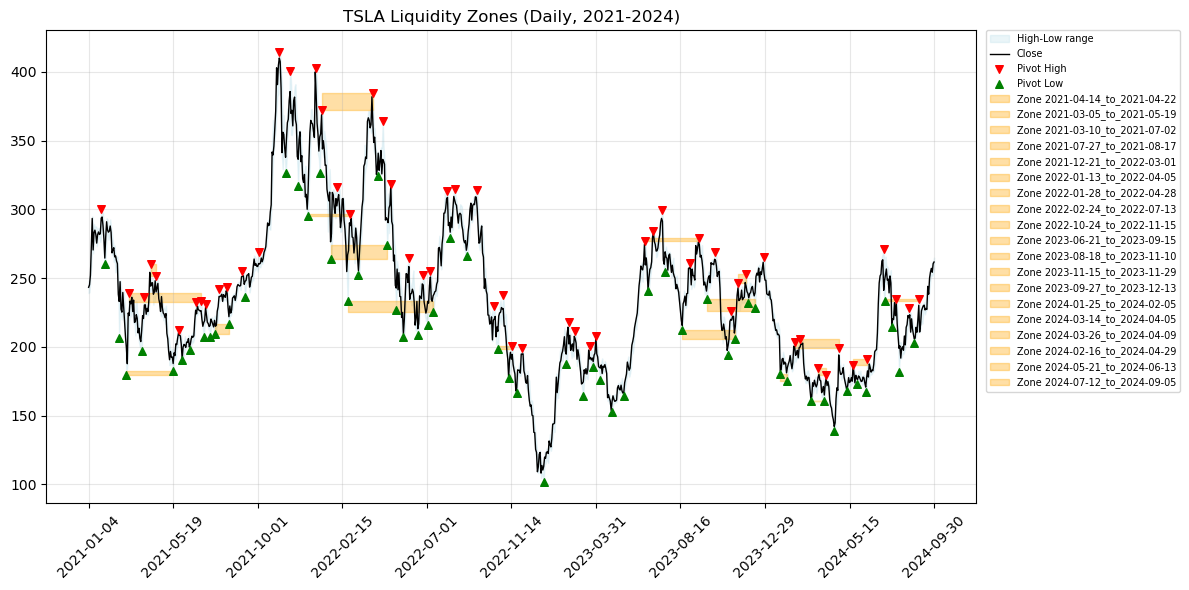

In [86]:
# ---------------------------------------------------------------------------
# Visualize Daily Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_daily, zones_df_daily,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Daily, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)



## Part 4 — Hourly (LTF) Liquidity Zone Analysis *(Primary)*

This is the **primary** zone detection pass — LTF hourly zones are the direct input for intraday sweep detection (Part 5) and for both model training sets.

Zones are built using a **three-layer filter** to ensure only the highest-conviction price levels are retained:

| Layer | Filter | Controlled by |
|---|---|---|
| **Layer 1** | ATR/pivot structure — local high/low with `pivot_left_right` bars each side | `pivot_left_right`, `atr_merge_mult` |
| **Layer 2** | Volume + absorption — pivot bar must have above-average volume **and** a high absorption score (heavy volume, small body) | `vol_mult`, `MIN_ABSORPTION_SCORE` |
| **Layer 3** | MIDAS institutional confirmation — zone-level average of a dark-pool/order-flow metric must exceed the Nth percentile | `MIDAS_CONFIRM_FIELD`, `MIDAS_CONFIRM_PCT` |

Layer 1+2 produces the **baseline zone set** — the "no order-level data" feature set for the first model.  
Layer 1+2+3 produces the **MIDAS-enriched zone set** — the enriched feature set for the second model.


In [87]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Hourly (LTF) [PRIMARY — intraday sweep detection]
# All three layers are applied via identify_liquidity_zones() in one call:
#   Layer 1: ATR/pivot structure (pivot_left_right, atr_merge_mult)
#   Layer 2: volume (vol_mult) + absorption (MIN_ABSORPTION_SCORE)
#   Layer 3: MIDAS enrichment + filter (MIDAS_CONFIRM_FIELD, MIDAS_CONFIRM_PCT)
# Output:
#   zones_df_hourly          — Layer 1+2 baseline  → "no order-level data" model
#   zones_df_hourly_enriched — Layer 1+2+3 enriched → "with order-level data" model
# ---------------------------------------------------------------------------
_hourly = reload_hourly.copy()
_hourly.columns = [c.lower() for c in _hourly.columns]

# Normalize volume column name (required for Layer 2 volume filter)
_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in _hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in _hourly.columns:
            _hourly = _hourly.rename(columns={alias: "volume"})
            print(f"[Info] Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column found — volume filtering disabled for hourly data.")

for col in ["open", "high", "low", "close"]:
    if col not in _hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data. Columns: {_hourly.columns.tolist()}")

print(f"Hourly columns: {_hourly.columns.tolist()}")
print("\n=== Processing Hourly Data (LTF — primary) ===")

# Single call: applies all three layers, returns both zone sets and POC values
# MULTI-DAY ZONES (structural context — 90-day merging window)
df_z_hourly_multiday, zones_df_hourly_multiday, zones_df_hourly_multiday_enriched, poc_price_hourly_md, poc_volume_hourly_md = identify_liquidity_zones(
    _hourly,
    pivot_left_right=5, atr_len=14, atr_merge_mult=1.0,
    require_volume=("volume" in _hourly.columns), vol_len=20, vol_mult=1.0,
    min_touches=2, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=MIN_ABSORPTION_SCORE,
    max_merge_gap_days=90,                      # ← MULTI-DAY: allow zones to span up to 90 days
    vol_profile_bin=VOL_PROFILE_BIN_HOURLY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)
print(f"MULTI-DAY Zones (90-day merging): {len(zones_df_hourly_multiday)} zones")
if poc_price_hourly_md is not None:
    print(f"  POC: ${poc_price_hourly_md:.2f} | Volume: {poc_volume_hourly_md:,.0f}")

# SAME-DAY ZONES (intraday focus — no cross-day merging)
df_z_hourly_sameday, zones_df_hourly_sameday, zones_df_hourly_sameday_enriched, poc_price_hourly_sd, poc_volume_hourly_sd = identify_liquidity_zones(
    _hourly,
    pivot_left_right=5, atr_len=14, atr_merge_mult=1.0,
    require_volume=("volume" in _hourly.columns), vol_len=20, vol_mult=1.0,
    min_touches=2, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=MIN_ABSORPTION_SCORE,
    max_merge_gap_days=0,                       # ← SAME-DAY: no cross-day zone merging
    vol_profile_bin=VOL_PROFILE_BIN_HOURLY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)
print(f"SAME-DAY Zones (intraday only):   {len(zones_df_hourly_sameday)} zones")
if poc_price_hourly_sd is not None:
    print(f"  POC: ${poc_price_hourly_sd:.2f} | Volume: {poc_volume_hourly_sd:,.0f}")

# SAME-DAY ZONES - OPTIMIZED for INTRADAY (tuned parameters)
print("\n▶ Generating OPTIMIZED same-day zones (reduced absorption, pivot window, vol_mult)...")
df_z_hourly_sameday_opt, zones_df_hourly_sameday_opt, zones_df_hourly_sameday_opt_enriched, poc_price_hourly_sd_opt, poc_volume_hourly_sd_opt = identify_liquidity_zones(
    _hourly,
    pivot_left_right=INTRADAY_PIVOT_WINDOW, atr_len=14, atr_merge_mult=1.0,
    require_volume=("volume" in _hourly.columns), vol_len=20, vol_mult=INTRADAY_VOL_MULT,
    min_touches=INTRADAY_MIN_TOUCHES, unique_pivots=False, use_both_high_low_pivots=True,
    min_absorption=INTRADAY_ABSORPTION_SCORE,
    max_merge_gap_days=0,
    vol_profile_bin=VOL_PROFILE_BIN_HOURLY,
    midas_df=midas_df if USE_MIDAS else None,
    midas_confirm_field=MIDAS_CONFIRM_FIELD,
    midas_confirm_pct=MIDAS_CONFIRM_PCT,
)
print(f"SAME-DAY Zones (OPTIMIZED):       {len(zones_df_hourly_sameday_opt)} zones")
if poc_price_hourly_sd_opt is not None:
    print(f"  POC: ${poc_price_hourly_sd_opt:.2f} | Volume: {poc_volume_hourly_sd_opt:,.0f}")

# For backward compatibility, assign primary zones to the multi-day set
# (These will be used in downstream analysis/visualization)
df_z_hourly = df_z_hourly_multiday
zones_df_hourly = zones_df_hourly_multiday
zones_df_hourly_enriched = zones_df_hourly_multiday_enriched
poc_price_hourly = poc_price_hourly_md
poc_volume_hourly = poc_volume_hourly_md

print("\n" + "=" * 70)
print("HOURLY ZONE COMPARISON: MULTI-DAY vs SAME-DAY")
print("=" * 70)
print(f"\nStructural (Multi-Day, 90-day merging):")
print(f"  Baseline zones:           {len(zones_df_hourly_multiday):>4}")
print(f"  MIDAS-enriched zones:     {len(zones_df_hourly_multiday_enriched):>4}")

print(f"\nIntraday (Same-Day, no cross-day merging):")
print(f"  Baseline zones:           {len(zones_df_hourly_sameday):>4}")
print(f"  MIDAS-enriched zones:     {len(zones_df_hourly_sameday_enriched):>4}")

multiday_avg_span = (zones_df_hourly_multiday['last_time'] - zones_df_hourly_multiday['first_time']).dt.days.mean() if len(zones_df_hourly_multiday) > 0 else 0
sameday_avg_span = (zones_df_hourly_sameday['last_time'] - zones_df_hourly_sameday['first_time']).dt.days.mean() if len(zones_df_hourly_sameday) > 0 else 0

print(f"\nAverage zone lifespan:")
print(f"  Multi-day zones: {multiday_avg_span:.2f} days")
print(f"  Same-day zones:  {sameday_avg_span:.2f} days")
print("=" * 70)

# ------------------------------------------------------------------
# Zone count summary: three-layer progression
# ------------------------------------------------------------------
print(f"\n{'─'*68}")
print(f"  LTF Zone Count — Three-Layer Filter Progression")
print(f"{'─'*68}")
print(f"  Multi-Day:   Layer 1+2: {len(zones_df_hourly_multiday):>4} | Layer 1+2+3: {len(zones_df_hourly_multiday_enriched):>4}")
print(f"  Same-Day:    Layer 1+2: {len(zones_df_hourly_sameday):>4} | Layer 1+2+3: {len(zones_df_hourly_sameday_enriched):>4}")
print(f"{'─'*68}")

# ------------------------------------------------------------------
# Comparison: baseline (no order-level data) vs MIDAS-enriched zones
# ------------------------------------------------------------------
_base_zone_cols_h = [c for c in [
    "zone_id", "top", "bottom", "touches", "strength",
    "avg_absorption", "dist_to_poc", "poc_volume_ratio",
] if c in zones_df_hourly.columns]
_midas_zone_disp_h = [c for c in MIDAS_ZONE_COLS if c in zones_df_hourly.columns]

print("\n— LTF MULTI-DAY Zones: Layer 1+2 baseline (no order-level data) — top 10 by recency —")
display(zones_df_hourly_multiday[_base_zone_cols_h].head(10))

print("\n— LTF SAME-DAY Zones: Layer 1+2 baseline (no order-level data) — top 10 by recency —")
display(zones_df_hourly_sameday[_base_zone_cols_h].head(10))

if _midas_zone_disp_h:
    _conf_cols = ["zone_id"] + [c for c in _base_zone_cols_h if c != "zone_id"] + _midas_zone_disp_h
    _conf_cols_md = [c for c in _conf_cols if c in zones_df_hourly_multiday_enriched.columns]
    _conf_cols_sd = [c for c in _conf_cols if c in zones_df_hourly_sameday_enriched.columns]
    
    print(f"\n— LTF MULTI-DAY Zones: Layer 1+2+3 MIDAS-enriched ({len(zones_df_hourly_multiday_enriched)} zones) —")
    if len(zones_df_hourly_multiday_enriched) > 0:
        display(zones_df_hourly_multiday_enriched[_conf_cols_md].head(10))
    
    print(f"\n— LTF SAME-DAY Zones: Layer 1+2+3 MIDAS-enriched ({len(zones_df_hourly_sameday_enriched)} zones) —")
    if len(zones_df_hourly_sameday_enriched) > 0:
        display(zones_df_hourly_sameday_enriched[_conf_cols_sd].head(10))

Hourly columns: ['open', 'high', 'low', 'close', '% change', 'volume', 'vol_roll_20', 'vol_roll_std', 'vol_ratio', 'vol_ratio_zscore', 'vol_spike', 'absorption_score']

=== Processing Hourly Data (LTF — primary) ===
Layer 3 MIDAS filter (hidden_rate_avg >= 50th pct = 30.712): 89/177 zones retained
MULTI-DAY Zones (90-day merging): 177 zones
  POC: $229.25 | Volume: 579,486,916
Layer 3 MIDAS filter (hidden_rate_avg >= 50th pct = 24.179): 12/23 zones retained
SAME-DAY Zones (intraday only):   23 zones
  POC: $229.25 | Volume: 579,486,916

▶ Generating OPTIMIZED same-day zones (reduced absorption, pivot window, vol_mult)...
Layer 3 MIDAS filter (hidden_rate_avg >= 50th pct = 30.252): 347/691 zones retained
SAME-DAY Zones (OPTIMIZED):       691 zones
  POC: $229.25 | Volume: 579,486,916

HOURLY ZONE COMPARISON: MULTI-DAY vs SAME-DAY

Structural (Multi-Day, 90-day merging):
  Baseline zones:            177
  MIDAS-enriched zones:       89

Intraday (Same-Day, no cross-day merging):
  Baseli

,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio
0,2021-01-15_to_2021-01-19,286.63,283.01,2,0.026526,7.474472,55.570,1.159127
1,2021-01-25_to_2021-01-26,300.13,298.63,2,0.026739,2.645406,70.130,0.838072
2,2021-01-08_to_2021-02-08,294.83,292.53,2,0.026998,8.669269,64.430,1.225861
3,2021-01-22_to_2021-02-11,276.63,276.23,2,0.025994,3.616361,47.180,1.143701
4,2021-01-15_to_2021-02-16,273.67,273.03,2,0.026314,7.101267,44.100,1.618305
5,2021-01-28_to_2021-02-19,267.00,265.60,3,0.041018,5.436378,37.050,1.957968
6,2021-03-25_to_2021-03-29,203.32,198.67,2,0.028067,1.779393,28.255,2.762372
7,2021-03-17_to_2021-04-01,234.58,230.81,2,0.027907,2.766211,3.445,2.490295
8,2021-04-05_to_2021-04-12,235.85,234.93,2,0.028534,6.891171,6.140,2.898149
9,2021-01-29_to_2021-04-14,261.78,260.03,3,0.043475,4.548910,31.655,2.354692



— LTF SAME-DAY Zones: Layer 1+2 baseline (no order-level data) — top 10 by recency —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio
0,2021-08-31_to_2021-09-01,247.33,246.73,2,0.029996,5.549409,17.780,3.967641
1,2021-09-17_to_2021-09-17,253.67,253.58,2,0.030728,17.012681,24.375,2.673474
2,2021-09-29_to_2021-09-30,264.50,263.03,2,0.031008,2.985655,34.515,2.411539
3,2021-10-21_to_2021-10-22,303.33,300.00,2,0.032515,3.259349,72.415,1.253960
4,2021-10-27_to_2021-10-28,360.33,356.96,2,0.033167,11.921263,129.395,0.517010
5,2021-11-17_to_2021-11-18,373.21,370.66,2,0.033516,3.751321,142.685,0.119868
6,2022-03-01_to_2022-03-02,296.63,295.28,2,0.036823,1.990941,66.705,1.106928
7,2022-05-20_to_2022-05-20,211.00,211.00,2,0.040518,2.298675,18.250,1.920760
8,2022-10-26_to_2022-10-27,233.69,230.49,2,0.049612,2.521615,2.840,2.169429
9,2022-12-29_to_2022-12-30,124.48,123.57,2,0.057061,3.607422,105.225,0.269454



— LTF MULTI-DAY Zones: Layer 1+2+3 MIDAS-enriched (89 zones) —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-01-15_to_2021-01-19,286.63,283.01,2,0.026526,7.474472,55.570,1.159127,10.387258,34.237010,32.916641,6.397417,90.108373,48.314849
1,2021-01-25_to_2021-01-26,300.13,298.63,2,0.026739,2.645406,70.130,0.838072,10.288741,35.791916,32.244626,6.586118,89.828516,48.324117
2,2021-01-08_to_2021-02-08,294.83,292.53,2,0.026998,8.669269,64.430,1.225861,10.275632,36.948114,33.176085,6.351552,90.316534,50.043585
3,2021-01-22_to_2021-02-11,276.63,276.23,2,0.025994,3.616361,47.180,1.143701,10.771892,37.417418,33.089965,5.598293,91.126170,52.156299
4,2021-01-15_to_2021-02-16,273.67,273.03,2,0.026314,7.101267,44.100,1.618305,11.040762,36.589374,32.734433,5.544921,91.095461,51.579433
5,2021-01-28_to_2021-02-19,267.00,265.60,3,0.041018,5.436378,37.050,1.957968,12.344969,36.584644,32.843303,4.850470,91.574723,53.337202
6,2021-03-25_to_2021-03-29,203.32,198.67,2,0.028067,1.779393,28.255,2.762372,18.406155,38.832644,29.916115,2.753353,91.546916,54.974500
7,2021-03-17_to_2021-04-01,234.58,230.81,2,0.027907,2.766211,3.445,2.490295,17.336799,39.812307,31.006662,2.970322,91.169249,53.612444
8,2021-04-05_to_2021-04-12,235.85,234.93,2,0.028534,6.891171,6.140,2.898149,20.159767,35.761790,27.693229,2.412704,90.761375,50.952018
9,2021-01-29_to_2021-04-14,261.78,260.03,3,0.043475,4.548910,31.655,2.354692,15.665593,37.478601,31.710875,3.558595,91.483021,53.753502



— LTF SAME-DAY Zones: Layer 1+2+3 MIDAS-enriched (12 zones) —


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-08-31_to_2021-09-01,247.33,246.73,2,0.029996,5.549409,17.780,3.967641,24.692379,39.505882,31.090756,2.095102,88.546499,47.068767
1,2021-09-17_to_2021-09-17,253.67,253.58,2,0.030728,17.012681,24.375,2.673474,18.341730,38.871342,30.554826,3.199712,85.436064,44.140841
2,2021-09-29_to_2021-09-30,264.50,263.03,2,0.031008,2.985655,34.515,2.411539,22.543168,38.384038,27.791363,2.319133,87.291550,46.656322
3,2021-10-21_to_2021-10-22,303.33,300.00,2,0.032515,3.259349,72.415,1.253960,12.498465,34.844788,27.528750,4.166383,86.653860,44.946528
4,2021-10-27_to_2021-10-28,360.33,356.96,2,0.033167,11.921263,129.395,0.517010,12.381053,41.375587,33.987512,4.314591,87.408324,46.846386
5,2021-11-17_to_2021-11-18,373.21,370.66,2,0.033516,3.751321,142.685,0.119868,11.149556,39.000921,31.698551,3.601517,91.909079,55.201818
6,2022-03-01_to_2022-03-02,296.63,295.28,2,0.036823,1.990941,66.705,1.106928,12.856166,39.356604,33.157239,4.979332,91.748212,58.171991
7,2022-05-20_to_2022-05-20,211.00,211.00,2,0.040518,2.298675,18.250,1.920760,11.963128,36.354516,38.121431,7.640109,92.417371,54.627881
8,2022-10-26_to_2022-10-27,233.69,230.49,2,0.049612,2.521615,2.840,2.169429,14.413255,35.319690,28.724420,4.173697,73.726563,31.815371
9,2022-12-29_to_2022-12-30,124.48,123.57,2,0.057061,3.607422,105.225,0.269454,17.663288,25.613320,20.068719,2.959142,72.976688,24.247210


In [88]:

# ---------------------------------------------------------------------------
# INTRADAY OPTIMIZATION IMPACT ANALYSIS
# Compare: Strict (original) vs Optimized (tuned) parameters
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("INTRADAY ZONE DETECTION: PARAMETER OPTIMIZATION IMPACT")
print("=" * 80)

# Create comparison dataframe
comparison_data = {
    'Setting': [
        'Pivot Window',
        'Volume Multiplier',
        'Absorption Score',
        'Min Touches',
        '',
        'Baseline Zones',
        'MIDAS-Enriched',
        'Enrichment Ratio',
        'Avg Zone Span (days)',
        'Avg Zone Strength'
    ],
    'STRICT (Original)': [
        '5 hours',
        '1.0×',
        '0.5',
        '2',
        '',
        f'{len(zones_df_hourly_sameday)}',
        f'{len(zones_df_hourly_sameday_enriched)}',
        f'{len(zones_df_hourly_sameday_enriched)/max(len(zones_df_hourly_sameday),1)*100:.1f}%',
        f'{(zones_df_hourly_sameday["last_time"] - zones_df_hourly_sameday["first_time"]).dt.days.mean():.2f}' if len(zones_df_hourly_sameday) > 0 else 'N/A',
        f'{zones_df_hourly_sameday["strength"].mean():.2f}' if len(zones_df_hourly_sameday) > 0 else 'N/A',
    ],
    'OPTIMIZED (Tuned)': [
        f'{INTRADAY_PIVOT_WINDOW} hours',
        f'{INTRADAY_VOL_MULT}×',
        f'{INTRADAY_ABSORPTION_SCORE}',
        f'{INTRADAY_MIN_TOUCHES}',
        '',
        f'{len(zones_df_hourly_sameday_opt)}',
        f'{len(zones_df_hourly_sameday_opt_enriched)}',
        f'{len(zones_df_hourly_sameday_opt_enriched)/max(len(zones_df_hourly_sameday_opt),1)*100:.1f}%',
        f'{(zones_df_hourly_sameday_opt["last_time"] - zones_df_hourly_sameday_opt["first_time"]).dt.days.mean():.2f}' if len(zones_df_hourly_sameday_opt) > 0 else 'N/A',
        f'{zones_df_hourly_sameday_opt["strength"].mean():.2f}' if len(zones_df_hourly_sameday_opt) > 0 else 'N/A',
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "─" * 80)
print("PARAMETER & RESULTS COMPARISON")
print("─" * 80)
display(comparison_df)

# Calculate improvement factor
improvement_factor = len(zones_df_hourly_sameday_opt) / max(len(zones_df_hourly_sameday), 1)
print(f"\n📊 ZONE DETECTION IMPROVEMENT: {improvement_factor:.1f}× increase")
print(f"   Strict setting:   {len(zones_df_hourly_sameday):>4} zones")
print(f"   Optimized:        {len(zones_df_hourly_sameday_opt):>4} zones")
print(f"   Gain:             {len(zones_df_hourly_sameday_opt) - len(zones_df_hourly_sameday):>4} zones (+{(improvement_factor-1)*100:.0f}%)")

# Detailed metrics comparison
print("\n" + "─" * 80)
print("ZONE QUALITY METRICS")
print("─" * 80)

if len(zones_df_hourly_sameday) > 0 and len(zones_df_hourly_sameday_opt) > 0:
    metrics_comparison = {
        'Metric': [
            'Average Touches',
            'Average Strength',
            'Median Absorption',
            'Max Zone Height',
            'Average Zone Height',
            'Zones with Vol Spike',
            'Zones > Median Strength'
        ],
        'STRICT': [
            f'{zones_df_hourly_sameday["touches"].mean():.2f}',
            f'{zones_df_hourly_sameday["strength"].mean():.2f}',
            f'{zones_df_hourly_sameday["avg_absorption"].median():.3f}',
            f'${zones_df_hourly_sameday["height"].max():.2f}',
            f'${zones_df_hourly_sameday["height"].mean():.2f}',
            'N/A',
            f'{(zones_df_hourly_sameday["strength"] > zones_df_hourly_sameday["strength"].median()).sum()}',
        ],
        'OPTIMIZED': [
            f'{zones_df_hourly_sameday_opt["touches"].mean():.2f}',
            f'{zones_df_hourly_sameday_opt["strength"].mean():.2f}',
            f'{zones_df_hourly_sameday_opt["avg_absorption"].median():.3f}',
            f'${zones_df_hourly_sameday_opt["height"].max():.2f}',
            f'${zones_df_hourly_sameday_opt["height"].mean():.2f}',
            'N/A',
            f'{(zones_df_hourly_sameday_opt["strength"] > zones_df_hourly_sameday_opt["strength"].median()).sum()}',
        ]
    }
    metrics_df = pd.DataFrame(metrics_comparison)
    display(metrics_df)

# Top zones from optimized set
print("\n" + "─" * 80)
print("TOP 5 ZONES FROM OPTIMIZED (INTRADAY) DETECTION")
print("─" * 80)
if len(zones_df_hourly_sameday_opt) > 0:
    top_cols = [c for c in [
        "zone_id", "top", "bottom", "height", "touches", "strength",
        "avg_absorption", "dist_to_poc"
    ] if c in zones_df_hourly_sameday_opt.columns]
    top_zones = zones_df_hourly_sameday_opt.nlargest(5, 'strength')[top_cols]
    display(top_zones)
else:
    print("No zones detected with optimized settings")

print("\n" + "=" * 80)
print("✓ OPTIMIZATION COMPLETE — Use zones_df_hourly_sameday_opt for intraday sweep detection")
print("=" * 80)



INTRADAY ZONE DETECTION: PARAMETER OPTIMIZATION IMPACT

────────────────────────────────────────────────────────────────────────────────
PARAMETER & RESULTS COMPARISON
────────────────────────────────────────────────────────────────────────────────


,Setting,STRICT (Original),OPTIMIZED (Tuned)
0,Pivot Window,5 hours,3 hours
1,Volume Multiplier,1.0×,1.2×
2,Absorption Score,0.5,0.3
3,Min Touches,2,1
4,,,
5,Baseline Zones,23,691
6,MIDAS-Enriched,12,347
7,Enrichment Ratio,52.2%,50.2%
8,Avg Zone Span (days),0.00,0.00
9,Avg Zone Strength,0.13,0.11



📊 ZONE DETECTION IMPROVEMENT: 30.0× increase
   Strict setting:     23 zones
   Optimized:         691 zones
   Gain:              668 zones (+2904%)

────────────────────────────────────────────────────────────────────────────────
ZONE QUALITY METRICS
────────────────────────────────────────────────────────────────────────────────


,Metric,STRICT,OPTIMIZED
0,Average Touches,2.00,1.04
1,Average Strength,0.13,0.11
2,Median Absorption,3.607,2.610
3,Max Zone Height,$3.37,$8.32
4,Average Zone Height,$1.37,$0.09
5,Zones with Vol Spike,N/A,N/A
6,Zones > Median Strength,11,344



────────────────────────────────────────────────────────────────────────────────
TOP 5 ZONES FROM OPTIMIZED (INTRADAY) DETECTION
────────────────────────────────────────────────────────────────────────────────


,zone_id,top,bottom,height,touches,strength,avg_absorption,dist_to_poc
690,2024-09-30_to_2024-09-30,264.86,264.86,0.0,1,17.058556,10.648543,35.61
688,2024-09-26_to_2024-09-26,261.75,261.75,0.0,1,4.236084,1.368777,32.50
689,2024-09-26_to_2024-09-26,251.53,251.53,0.0,1,4.145181,1.592243,22.28
687,2024-09-24_to_2024-09-24,257.19,257.19,0.0,1,2.902286,2.699353,27.94
686,2024-09-18_to_2024-09-18,231.61,231.61,0.0,1,1.388826,3.328374,2.36



✓ OPTIMIZATION COMPLETE — Use zones_df_hourly_sameday_opt for intraday sweep detection


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_39968/1120650361.py:56: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



Chart saved to charts/TSLA_Liquidity_Zones_(Hourly,_2021-2024).png


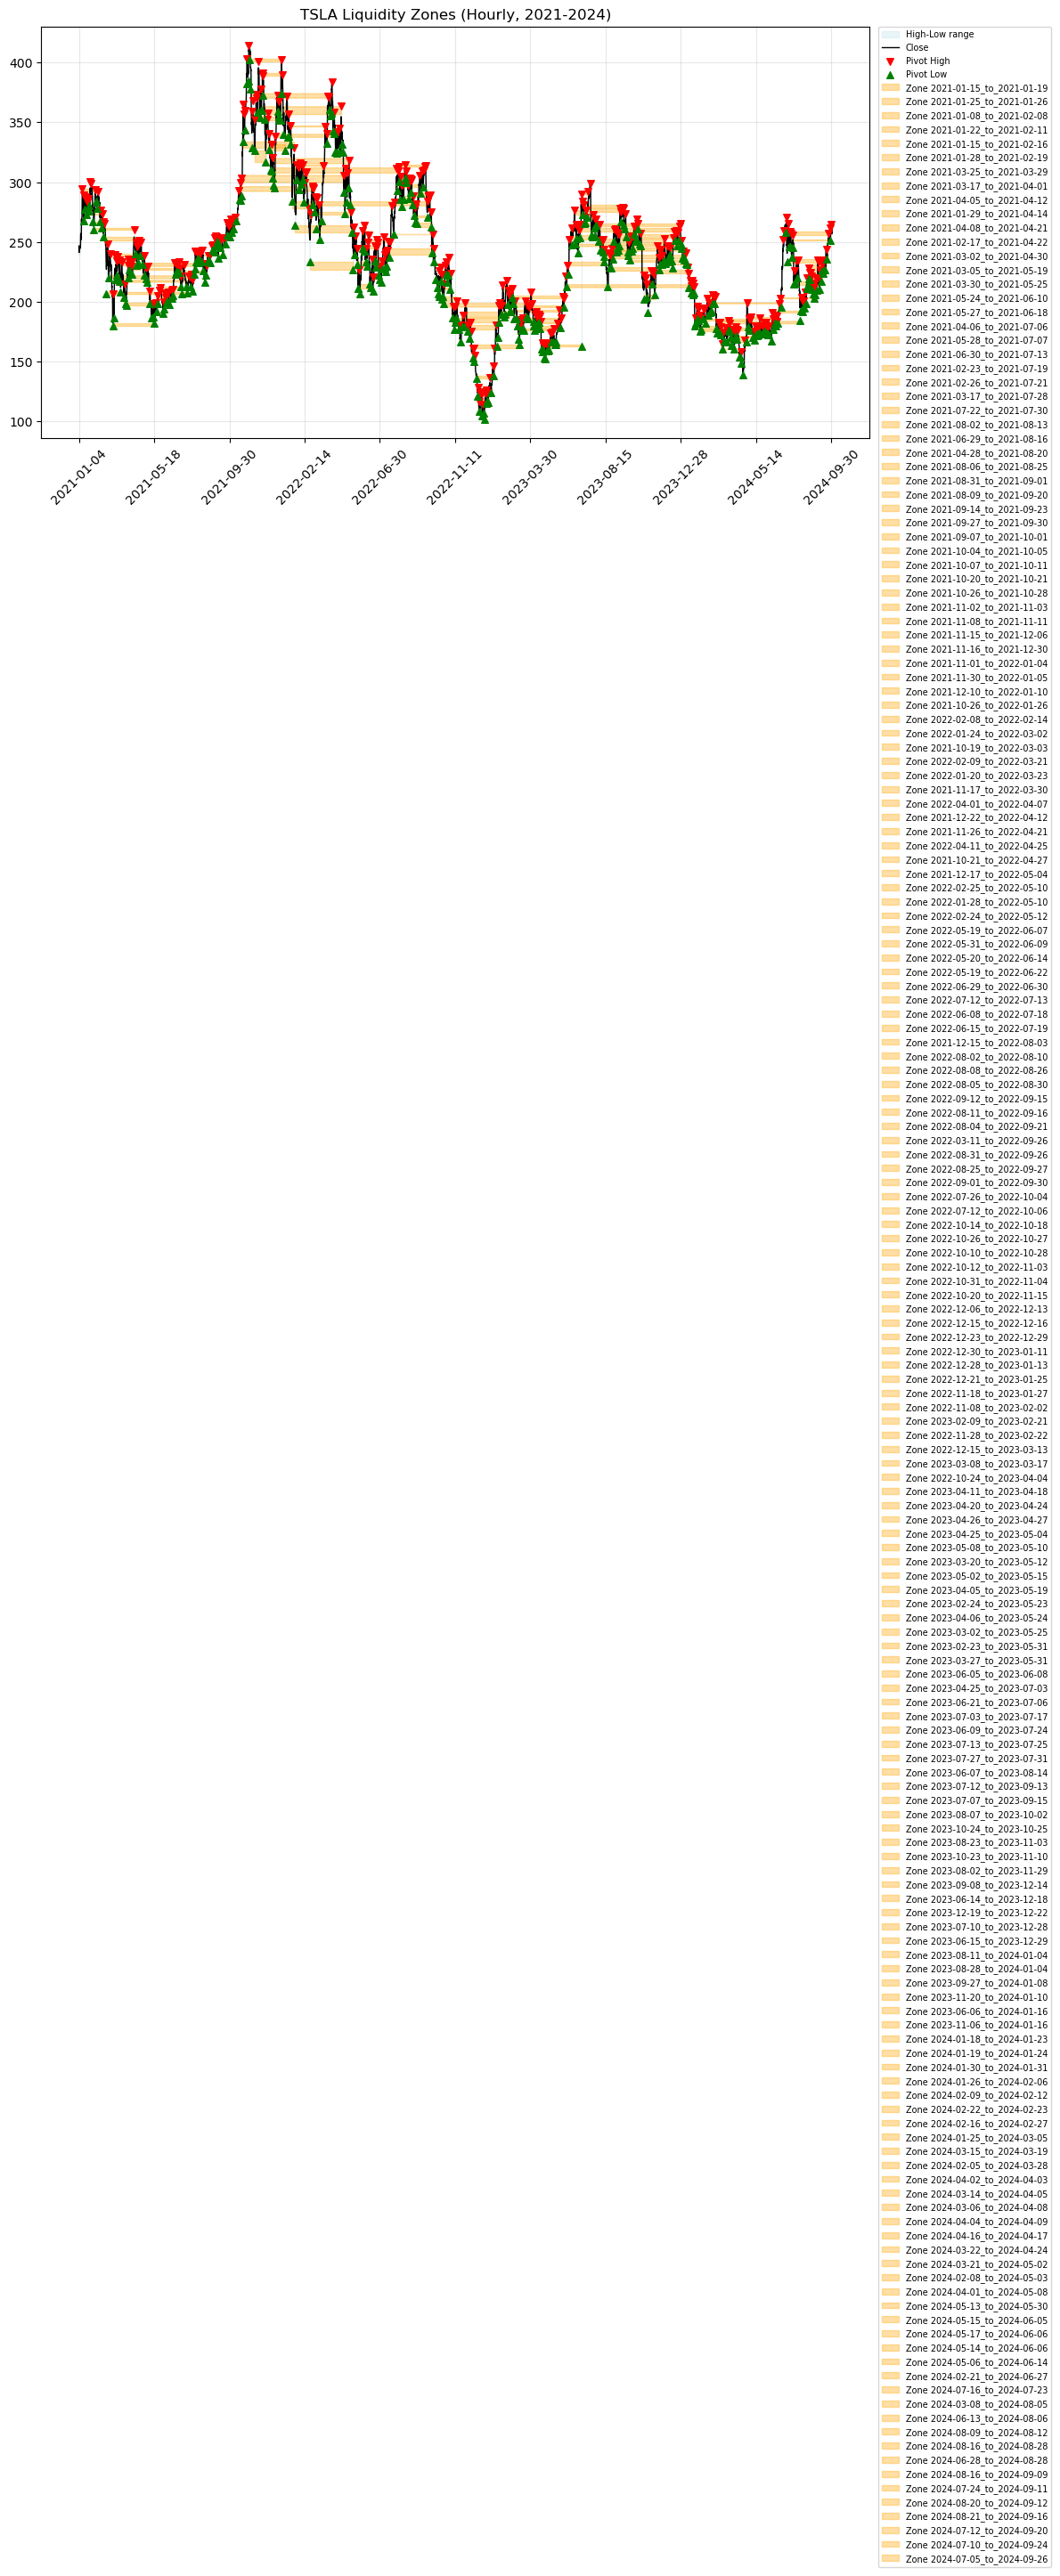

In [89]:
# ---------------------------------------------------------------------------
# Visualize Hourly Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_hourly, zones_df_hourly,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Hourly, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)


In [90]:

# ---------------------------------------------------------------------------
# INTRADAY LIQUIDITY ZONE VISUALIZATION - CANDLESTICK CHARTS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CANDLESTICK CHARTS: BUY-SIDE & SELL-SIDE LIQUIDITY ZONES (INTRADAY)")
print("=" * 70)

import plotly.graph_objects as go

# Use hourly data already loaded
price_data = reload_hourly.copy()
price_data.columns = price_data.columns.str.lower()
price_data = price_data.reset_index(drop=False)
# Handle both 'Datetime' and 'datetime' index names
if 'datetime' in price_data.columns:
    price_data = price_data.rename(columns={'datetime': 'timestamp'})
elif price_data.columns[0].lower() == 'datetime':
    price_data = price_data.rename(columns={price_data.columns[0]: 'timestamp'})
price_data['timestamp'] = pd.to_datetime(price_data['timestamp'])
price_data = price_data.sort_values('timestamp').reset_index(drop=True)

print(f"\n✓ Using hourly price data: {len(price_data)} candles")
print(f"  Date range: {price_data['timestamp'].min()} to {price_data['timestamp'].max()}")

# Classify zones as buy-side (support) or sell-side (resistance)
# Based on proximity to current price or volume profile
if len(zones_df_hourly) > 0:
    current_price = price_data['close'].iloc[-1]
    zones_df_hourly['zone_type'] = zones_df_hourly.apply(
        lambda row: 'SELL_SIDE' if row['top'] > current_price * 1.01 else 'BUY_SIDE',
        axis=1
    )
    
    print(f"\nZone Classification:")
    print(f"  Buy-side zones (support):     {(zones_df_hourly['zone_type'] == 'BUY_SIDE').sum()}")
    print(f"  Sell-side zones (resistance): {(zones_df_hourly['zone_type'] == 'SELL_SIDE').sum()}")
    
    # Function to create candlestick chart for a zone
    def plot_zone_candlestick(price_df, zone_row, chart_title):
        """Create candlestick chart for a specific liquidity zone"""
        try:
            zone_top = zone_row['top']
            zone_bottom = zone_row['bottom']
            zone_type = zone_row['zone_type']
            zone_time = pd.to_datetime(zone_row['first_time'])
            
            # Get context: 15 candles before zone first_time, 10 after
            # Find closest timestamp in price data
            closest_idx = (price_df['timestamp'] - zone_time).abs().argmin()
            
            if closest_idx < 0:
                return None
            
            start = max(0, closest_idx - 15)
            end = min(len(price_df) - 1, closest_idx + 10)
            
            subset = price_df.iloc[start:end+1].copy()
            
            # Create candlestick figure
            fig = go.Figure(data=[go.Candlestick(
                x=subset['timestamp'],
                open=subset['open'],
                high=subset['high'],
                low=subset['low'],
                close=subset['close'],
                name='TSLA Price'
            )])
            
            # Add liquidity zone shading
            if zone_type == 'BUY_SIDE':
                # Support zone - green
                fig.add_hrect(
                    y0=zone_bottom * 0.99,
                    y1=zone_top * 1.01,
                    fillcolor='green',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'green'
                zone_label = 'BUY-SIDE (Support)'
            else:
                # Resistance zone - red
                fig.add_hrect(
                    y0=zone_bottom * 0.99,
                    y1=zone_top * 1.01,
                    fillcolor='red',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'red'
                zone_label = 'SELL-SIDE (Resistance)'
            
            # Add zone mid-level line
            zone_mid = (zone_top + zone_bottom) / 2
            fig.add_hline(
                y=zone_mid,
                line_width=2,
                line_dash='dash',
                line_color=zone_color,
                annotation_text=f'{zone_label}<br>${zone_mid:.2f}',
                annotation_position='right',
                annotation=dict(font_size=10, bgcolor='rgba(255,255,255,0.8)')
            )
            
            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=13)),
                yaxis_title='Price (USD)',
                xaxis_title='Date & Time',
                template='plotly_white',
                height=500,
                width=1100,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                showlegend=True,
                font=dict(size=10),
                margin=dict(l=80, r=100, t=100, b=80)
            )
            
            return fig
            
        except Exception as e:
            print(f"      ✗ Error creating chart: {e}")
            return None
    
    # Plot top 3 BUY-SIDE zones
    print("\n" + "=" * 70)
    print("BUY-SIDE LIQUIDITY ZONES (SUPPORT) - INTRADAY VISUALIZATION")
    print("=" * 70)
    
    buy_zones = zones_df_hourly[zones_df_hourly['zone_type'] == 'BUY_SIDE'].nlargest(3, 'strength')
    
    for i, (idx, zone) in enumerate(buy_zones.iterrows(), 1):
        zone_height = zone['top'] - zone['bottom']
        title = f"BUY-SIDE ZONE #{i} | Level: ${zone['bottom']:.2f}-${zone['top']:.2f} | Touches: {zone['touches']} | Strength: {zone['strength']:.2f}"
        print(f"\n{i}. {zone['zone_id']} | Strength: {zone['strength']:.2f} | Absorption: {zone.get('avg_absorption', 0):.2f}")
        
        fig = plot_zone_candlestick(price_data, zone, title)
        if fig:
            fig.show()
        else:
            print(f"   → Could not create chart")
    
    # Plot top 3 SELL-SIDE zones
    print("\n" + "=" * 70)
    print("SELL-SIDE LIQUIDITY ZONES (RESISTANCE) - INTRADAY VISUALIZATION")
    print("=" * 70)
    
    sell_zones = zones_df_hourly[zones_df_hourly['zone_type'] == 'SELL_SIDE'].nlargest(3, 'strength')
    
    for i, (idx, zone) in enumerate(sell_zones.iterrows(), 1):
        zone_height = zone['top'] - zone['bottom']
        title = f"SELL-SIDE ZONE #{i} | Level: ${zone['bottom']:.2f}-${zone['top']:.2f} | Touches: {zone['touches']} | Strength: {zone['strength']:.2f}"
        print(f"\n{i}. {zone['zone_id']} | Strength: {zone['strength']:.2f} | Absorption: {zone.get('avg_absorption', 0):.2f}")
        
        fig = plot_zone_candlestick(price_data, zone, title)
        if fig:
            fig.show()
        else:
            print(f"   → Could not create chart")
    
    print("\n" + "=" * 70)
    print("✓ INTRADAY LIQUIDITY ZONE VISUALIZATION COMPLETE")
    print("=" * 70)
else:
    print("\n✗ No zones available for visualization")



CANDLESTICK CHARTS: BUY-SIDE & SELL-SIDE LIQUIDITY ZONES (INTRADAY)

✓ Using hourly price data: 6577 candles
  Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00

Zone Classification:
  Buy-side zones (support):     127
  Sell-side zones (resistance): 50

BUY-SIDE LIQUIDITY ZONES (SUPPORT) - INTRADAY VISUALIZATION

1. 2024-07-12_to_2024-09-20 | Strength: 15.46 | Absorption: 6.76



2. 2024-07-10_to_2024-09-24 | Strength: 12.42 | Absorption: 2.46



3. 2024-07-05_to_2024-09-26 | Strength: 9.04 | Absorption: 5.90



SELL-SIDE LIQUIDITY ZONES (RESISTANCE) - INTRADAY VISUALIZATION

1. 2023-07-10_to_2023-12-28 | Strength: 0.56 | Absorption: 9.17



2. 2022-03-11_to_2022-09-26 | Strength: 0.18 | Absorption: 3.31



3. 2023-07-12_to_2023-09-13 | Strength: 0.15 | Absorption: 7.25



✓ INTRADAY LIQUIDITY ZONE VISUALIZATION COMPLETE


In [91]:

# ---------------------------------------------------------------------------
# INTRADAY LIQUIDITY ZONE VISUALIZATION - SAME-DAY ZONES
# Focus: True intraday zones for sweep detection within single trading day
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CANDLESTICK CHARTS: SAME-DAY ZONES ONLY (INTRADAY FOCUS)")
print("=" * 70)

import plotly.graph_objects as go

# Use hourly data already loaded
price_data = reload_hourly.copy()
price_data.columns = price_data.columns.str.lower()
price_data = price_data.reset_index(drop=False)
if 'datetime' in price_data.columns:
    price_data = price_data.rename(columns={'datetime': 'timestamp'})
elif price_data.columns[0].lower() == 'datetime':
    price_data = price_data.rename(columns={price_data.columns[0]: 'timestamp'})
price_data['timestamp'] = pd.to_datetime(price_data['timestamp'])
price_data = price_data.sort_values('timestamp').reset_index(drop=True)

print(f"\n✓ Using hourly price data: {len(price_data)} candles")
print(f"  Date range: {price_data['timestamp'].min()} to {price_data['timestamp'].max()}")

# Classify zones as buy-side (support) or sell-side (resistance)
if len(zones_df_hourly_sameday) > 0:
    current_price = price_data['close'].iloc[-1]
    zones_df_hourly_sameday['zone_type'] = zones_df_hourly_sameday.apply(
        lambda row: 'SELL_SIDE' if row['top'] > current_price * 1.01 else 'BUY_SIDE',
        axis=1
    )
    
    print(f"\nSame-Day Zone Classification:")
    print(f"  Buy-side zones (support):     {(zones_df_hourly_sameday['zone_type'] == 'BUY_SIDE').sum()}")
    print(f"  Sell-side zones (resistance): {(zones_df_hourly_sameday['zone_type'] == 'SELL_SIDE').sum()}")
    
    # Function to create candlestick chart for a zone
    def plot_sameday_zone_candlestick(price_df, zone_row, chart_title):
        """Create candlestick chart for a same-day liquidity zone"""
        try:
            zone_top = zone_row['top']
            zone_bottom = zone_row['bottom']
            zone_type = zone_row['zone_type']
            zone_time = pd.to_datetime(zone_row['first_time'])
            
            # Get context: find closest timestamp and get ±5 candles before/after
            closest_idx = (price_df['timestamp'] - zone_time).abs().argmin()
            
            if closest_idx < 0:
                return None
            
            start = max(0, closest_idx - 8)
            end = min(len(price_df) - 1, closest_idx + 8)
            
            subset = price_df.iloc[start:end+1].copy()
            
            # Create candlestick figure
            fig = go.Figure(data=[go.Candlestick(
                x=subset['timestamp'],
                open=subset['open'],
                high=subset['high'],
                low=subset['low'],
                close=subset['close'],
                name='TSLA Price'
            )])
            
            # Add liquidity zone shading
            if zone_type == 'BUY_SIDE':
                # Support zone - green
                fig.add_hrect(
                    y0=zone_bottom * 0.99,
                    y1=zone_top * 1.01,
                    fillcolor='green',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'green'
                zone_label = 'BUY-SIDE (Support)'
            else:
                # Resistance zone - red
                fig.add_hrect(
                    y0=zone_bottom * 0.99,
                    y1=zone_top * 1.01,
                    fillcolor='red',
                    opacity=0.12,
                    layer='below',
                    line_width=0
                )
                zone_color = 'red'
                zone_label = 'SELL-SIDE (Resistance)'
            
            # Add zone mid-level line
            zone_mid = (zone_top + zone_bottom) / 2
            fig.add_hline(
                y=zone_mid,
                line_width=2,
                line_dash='dash',
                line_color=zone_color,
                annotation_text=f'{zone_label}<br>${zone_mid:.2f}',
                annotation_position='right',
                annotation=dict(font_size=10, bgcolor='rgba(255,255,255,0.8)')
            )
            
            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=13)),
                yaxis_title='Price (USD)',
                xaxis_title='Date & Time',
                template='plotly_white',
                height=450,
                width=1000,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                showlegend=True,
                font=dict(size=10),
                margin=dict(l=80, r=100, t=100, b=80)
            )
            
            return fig
            
        except Exception as e:
            print(f"      ✗ Error creating chart: {e}")
            return None
    
    # Plot top 3 BUY-SIDE same-day zones
    print("\n" + "=" * 70)
    print("SAME-DAY BUY-SIDE ZONES (SUPPORT) - INTRADAY SWEEP FOCUS")
    print("=" * 70)
    
    buy_zones_sd = zones_df_hourly_sameday[zones_df_hourly_sameday['zone_type'] == 'BUY_SIDE'].nlargest(3, 'strength')
    
    for i, (idx, zone) in enumerate(buy_zones_sd.iterrows(), 1):
        zone_height = zone['top'] - zone['bottom']
        title = f"SAME-DAY BUY-SIDE #{i} | {zone['zone_id']} | ${zone['bottom']:.2f}-${zone['top']:.2f} | Strength: {zone['strength']:.2f}"
        print(f"\n{i}. {zone['zone_id']} | Strength: {zone['strength']:.2f} | Touches: {zone['touches']} | Absorption: {zone.get('avg_absorption', 0):.2f}")
        
        fig = plot_sameday_zone_candlestick(price_data, zone, title)
        if fig:
            fig.show()
        else:
            print(f"   → Could not create chart")
    
    # Plot top 3 SELL-SIDE same-day zones
    print("\n" + "=" * 70)
    print("SAME-DAY SELL-SIDE ZONES (RESISTANCE) - INTRADAY SWEEP FOCUS")
    print("=" * 70)
    
    sell_zones_sd = zones_df_hourly_sameday[zones_df_hourly_sameday['zone_type'] == 'SELL_SIDE'].nlargest(3, 'strength')
    
    for i, (idx, zone) in enumerate(sell_zones_sd.iterrows(), 1):
        zone_height = zone['top'] - zone['bottom']
        title = f"SAME-DAY SELL-SIDE #{i} | {zone['zone_id']} | ${zone['bottom']:.2f}-${zone['top']:.2f} | Strength: {zone['strength']:.2f}"
        print(f"\n{i}. {zone['zone_id']} | Strength: {zone['strength']:.2f} | Touches: {zone['touches']} | Absorption: {zone.get('avg_absorption', 0):.2f}")
        
        fig = plot_sameday_zone_candlestick(price_data, zone, title)
        if fig:
            fig.show()
        else:
            print(f"   → Could not create chart")
    
    print("\n" + "=" * 70)
    print("✓ INTRADAY ZONE VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nUSE THESE ZONES FOR:")
    print("  • Intraday sweep detection (same trading day)")
    print("  • Hour-by-hour liquidity analysis")
    print("  • Real-time trading signals within a session")
else:
    print("\n✗ No same-day zones available for visualization")



CANDLESTICK CHARTS: SAME-DAY ZONES ONLY (INTRADAY FOCUS)

✓ Using hourly price data: 6577 candles
  Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00

Same-Day Zone Classification:
  Buy-side zones (support):     18
  Sell-side zones (resistance): 5

SAME-DAY BUY-SIDE ZONES (SUPPORT) - INTRADAY SWEEP FOCUS

1. 2024-08-20_to_2024-08-21 | Strength: 0.87 | Touches: 2 | Absorption: 5.35



2. 2024-06-21_to_2024-06-21 | Strength: 0.34 | Touches: 2 | Absorption: 6.53



3. 2024-05-14_to_2024-05-15 | Strength: 0.26 | Touches: 2 | Absorption: 1.22



SAME-DAY SELL-SIDE ZONES (RESISTANCE) - INTRADAY SWEEP FOCUS

1. 2022-03-01_to_2022-03-02 | Strength: 0.04 | Touches: 2 | Absorption: 1.99



2. 2021-11-17_to_2021-11-18 | Strength: 0.03 | Touches: 2 | Absorption: 3.75



3. 2021-10-27_to_2021-10-28 | Strength: 0.03 | Touches: 2 | Absorption: 11.92



✓ INTRADAY ZONE VISUALIZATION COMPLETE

USE THESE ZONES FOR:
  • Intraday sweep detection (same trading day)
  • Hour-by-hour liquidity analysis
  • Real-time trading signals within a session


## Part 5 — Export Liquidity Zone Results to Excel

Save all zone analysis outputs to Excel workbooks for downstream analysis and model training.

| File | Contents |
|---|---|
| `TSLA_results_daily.xlsx` | HTF daily zone results (structural context) |
| `TSLA_results_hourly.xlsx` | LTF hourly zone results — **primary analysis** |

### Hourly workbook sheet layout (primary):

| Sheet | Contents |
|---|---|
| `OHLCV` | Price bars + bar-level volume features |
| `Liquidity_Zones` | All Layer 1+2 baseline zones with volume and MIDAS features |
| `MIDAS_Zones` | Zone-level sheet with institutional microstructure metrics (MIDAS) averaged over each zone's active window |
| `MIDAS_enriched_Zones` | Layer 1+2+3 zone subset (MIDAS-enriched), with all features used for model training |



In [92]:
# ---------------------------------------------------------------------------
# Save Results to Excel — Daily (context) & Hourly (primary)
# ---------------------------------------------------------------------------
ohlcv_base_cols = [
    "open", "high", "low", "close", "volume",
    "vol_roll_20", "vol_ratio", "vol_spike", "absorption_score",
]

for label, df_z, zones_df, zones_enriched in [
    # daily: structural context only
    ("daily",  df_z_daily,  zones_df_daily,  None),
    # hourly: both baseline and enriched sets
    ("hourly", df_z_hourly, zones_df_hourly, zones_df_hourly_enriched),
]:
    avail_ohlcv  = [c for c in ohlcv_base_cols if c in df_z.columns]

    excel_path = f"{TICKER}_results_{label}.xlsx"
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

        # ── Core sheets (shared output) ────────────────────────────
        ohlcv_zone = df_z[avail_ohlcv].assign(zone_id=df_z["zone_id"])
        ohlcv_zone.to_excel(writer, index=True,  sheet_name="OHLCV")
        zones_df.to_excel(writer,   index=False, sheet_name="Liquidity_Zones")

        # ── MIDAS zone and enriched views ──────────────────────────
        if USE_MIDAS and midas_df is not None:
            avail_midas_zone_cols  = [c for c in MIDAS_ZONE_COLS  if c in zones_df.columns]
            if avail_midas_zone_cols:
                zones_df[["zone_id"] + avail_midas_zone_cols].to_excel(
                    writer, index=False, sheet_name="MIDAS_Zones"
                )

            # Hourly-only: MIDAS-enriched zone set — Layer 1+2+3
            if zones_enriched is not None:
                _base_zcols = ["zone_id", "top", "bottom", "touches", "strength",
                               "avg_absorption", "dist_to_poc", "poc_volume_ratio"]
                _enh_zone_cols = [c for c in _base_zcols + avail_midas_zone_cols
                                  if c in zones_enriched.columns]
                zones_enriched[_enh_zone_cols].to_excel(
                    writer, index=False, sheet_name="MIDAS_enriched_Zones"
                )

    print(f"Saved {label} results -> {excel_path}")

Saved daily results -> TSLA_results_daily.xlsx
Saved hourly results -> TSLA_results_hourly.xlsx
